#### Step 1 导入相关包

In [121]:
import pandas as pd
import pickle

import matplotlib.pyplot as plt

In [122]:
# 设置格式
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

#### Step 2 加载数据

In [3]:
d_index_df = pd.read_csv('./citations_result/DI_index.csv')
d_index_df.head()

,patent_id,d_index
0,D580322,-0.369369
1,D620599,-0.107843
2,D633181,0.038710
3,D792235,-0.086667
4,D337815,-0.010638


In [4]:
d_index_df['patent_id'] = d_index_df['patent_id'].astype('str')

In [5]:
# 指定TSV文件路径
file_path = '../g_patent.tsv/g_patent.tsv'  # 替换为你的TSV文件路径

# 读取TSV文件
df_patent = pd.read_csv(file_path, sep='\t')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15220\774833127.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_patent = pd.read_csv(file_path, sep='\t')


In [6]:
df_patent['patent_id'] = df_patent['patent_id'].astype('str')

In [7]:
df_patent

,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename
0,10000000,utility,2018-06-19,Coherent LADAR using intra-pixel quadrature de...,B2,20,0,ipg180619.xml
1,10000001,utility,2018-06-19,Injection molding machine and mold thickness c...,B2,12,0,ipg180619.xml
2,10000002,utility,2018-06-19,Method for manufacturing polymer film and co-e...,B2,9,0,ipg180619.xml
3,10000003,utility,2018-06-19,Method for producing a container from a thermo...,B2,18,0,ipg180619.xml
4,10000004,utility,2018-06-19,"Process of obtaining a double-oriented film, c...",B2,6,0,ipg180619.xml
...,...,...,...,...,...,...,...,...
9163780,T998013,defensive publication,1980-09-02,Protection of insect pheromones from degradati...,I4,1,0,pftaps19800902_wk36.zip
9163781,T998014,defensive publication,1980-09-02,"Thiazolyl couplers, coupler compositions and p...",I4,3,0,pftaps19800902_wk36.zip
9163782,T999001,defensive publication,1980-10-07,Sack handling device,I4,1,0,pftaps19801007_wk41.zip
9163783,T999002,defensive publication,1980-10-07,Application of polymeric powders to a substrate,I4,7,0,pftaps19801007_wk41.zip


In [8]:
# 1. 一次性把日期列转成年份，非法日期会变成 NaT
df_patent['patent_year'] = (
    pd.to_datetime(df_patent['patent_date'], errors='coerce')   # 非法变 NaT
      .dt.year                                           # 取年份
      .fillna(1974)                                         # NaT 用 1974 或你指定的兜底年份
      .astype(int)
)

In [9]:
d_index_df_merged = (
    d_index_df
    .merge(
        df_patent[['patent_id', 'patent_year','num_claims','patent_type']],
        left_on='patent_id',          # 被引专利
        right_on='patent_id',             # df_application 的专利
        how='left'                       
    )
)

In [10]:
d_index_df_merged = d_index_df_merged[
    (d_index_df_merged['patent_year'] >= 1980) &
    (d_index_df_merged['patent_type'].str.lower() == 'utility')
].reset_index(drop=True)

In [11]:
d_index_df_merged

,patent_id,d_index,patent_year,num_claims,patent_type
0,4180867,0.292308,1980,16,utility
1,4180868,0.019573,1980,16,utility
2,4180869,0.333333,1980,10,utility
3,4180870,0.288991,1980,12,utility
4,4180871,-0.012821,1980,7,utility
...,...,...,...,...,...
5332545,RE34357,0.014742,1993,133,utility
5332546,RE31700,0.428571,1984,12,utility
5332547,RE31206,0.020000,1983,11,utility
5332548,RE31699,-0.070632,1984,15,utility


#### Step 3 分析

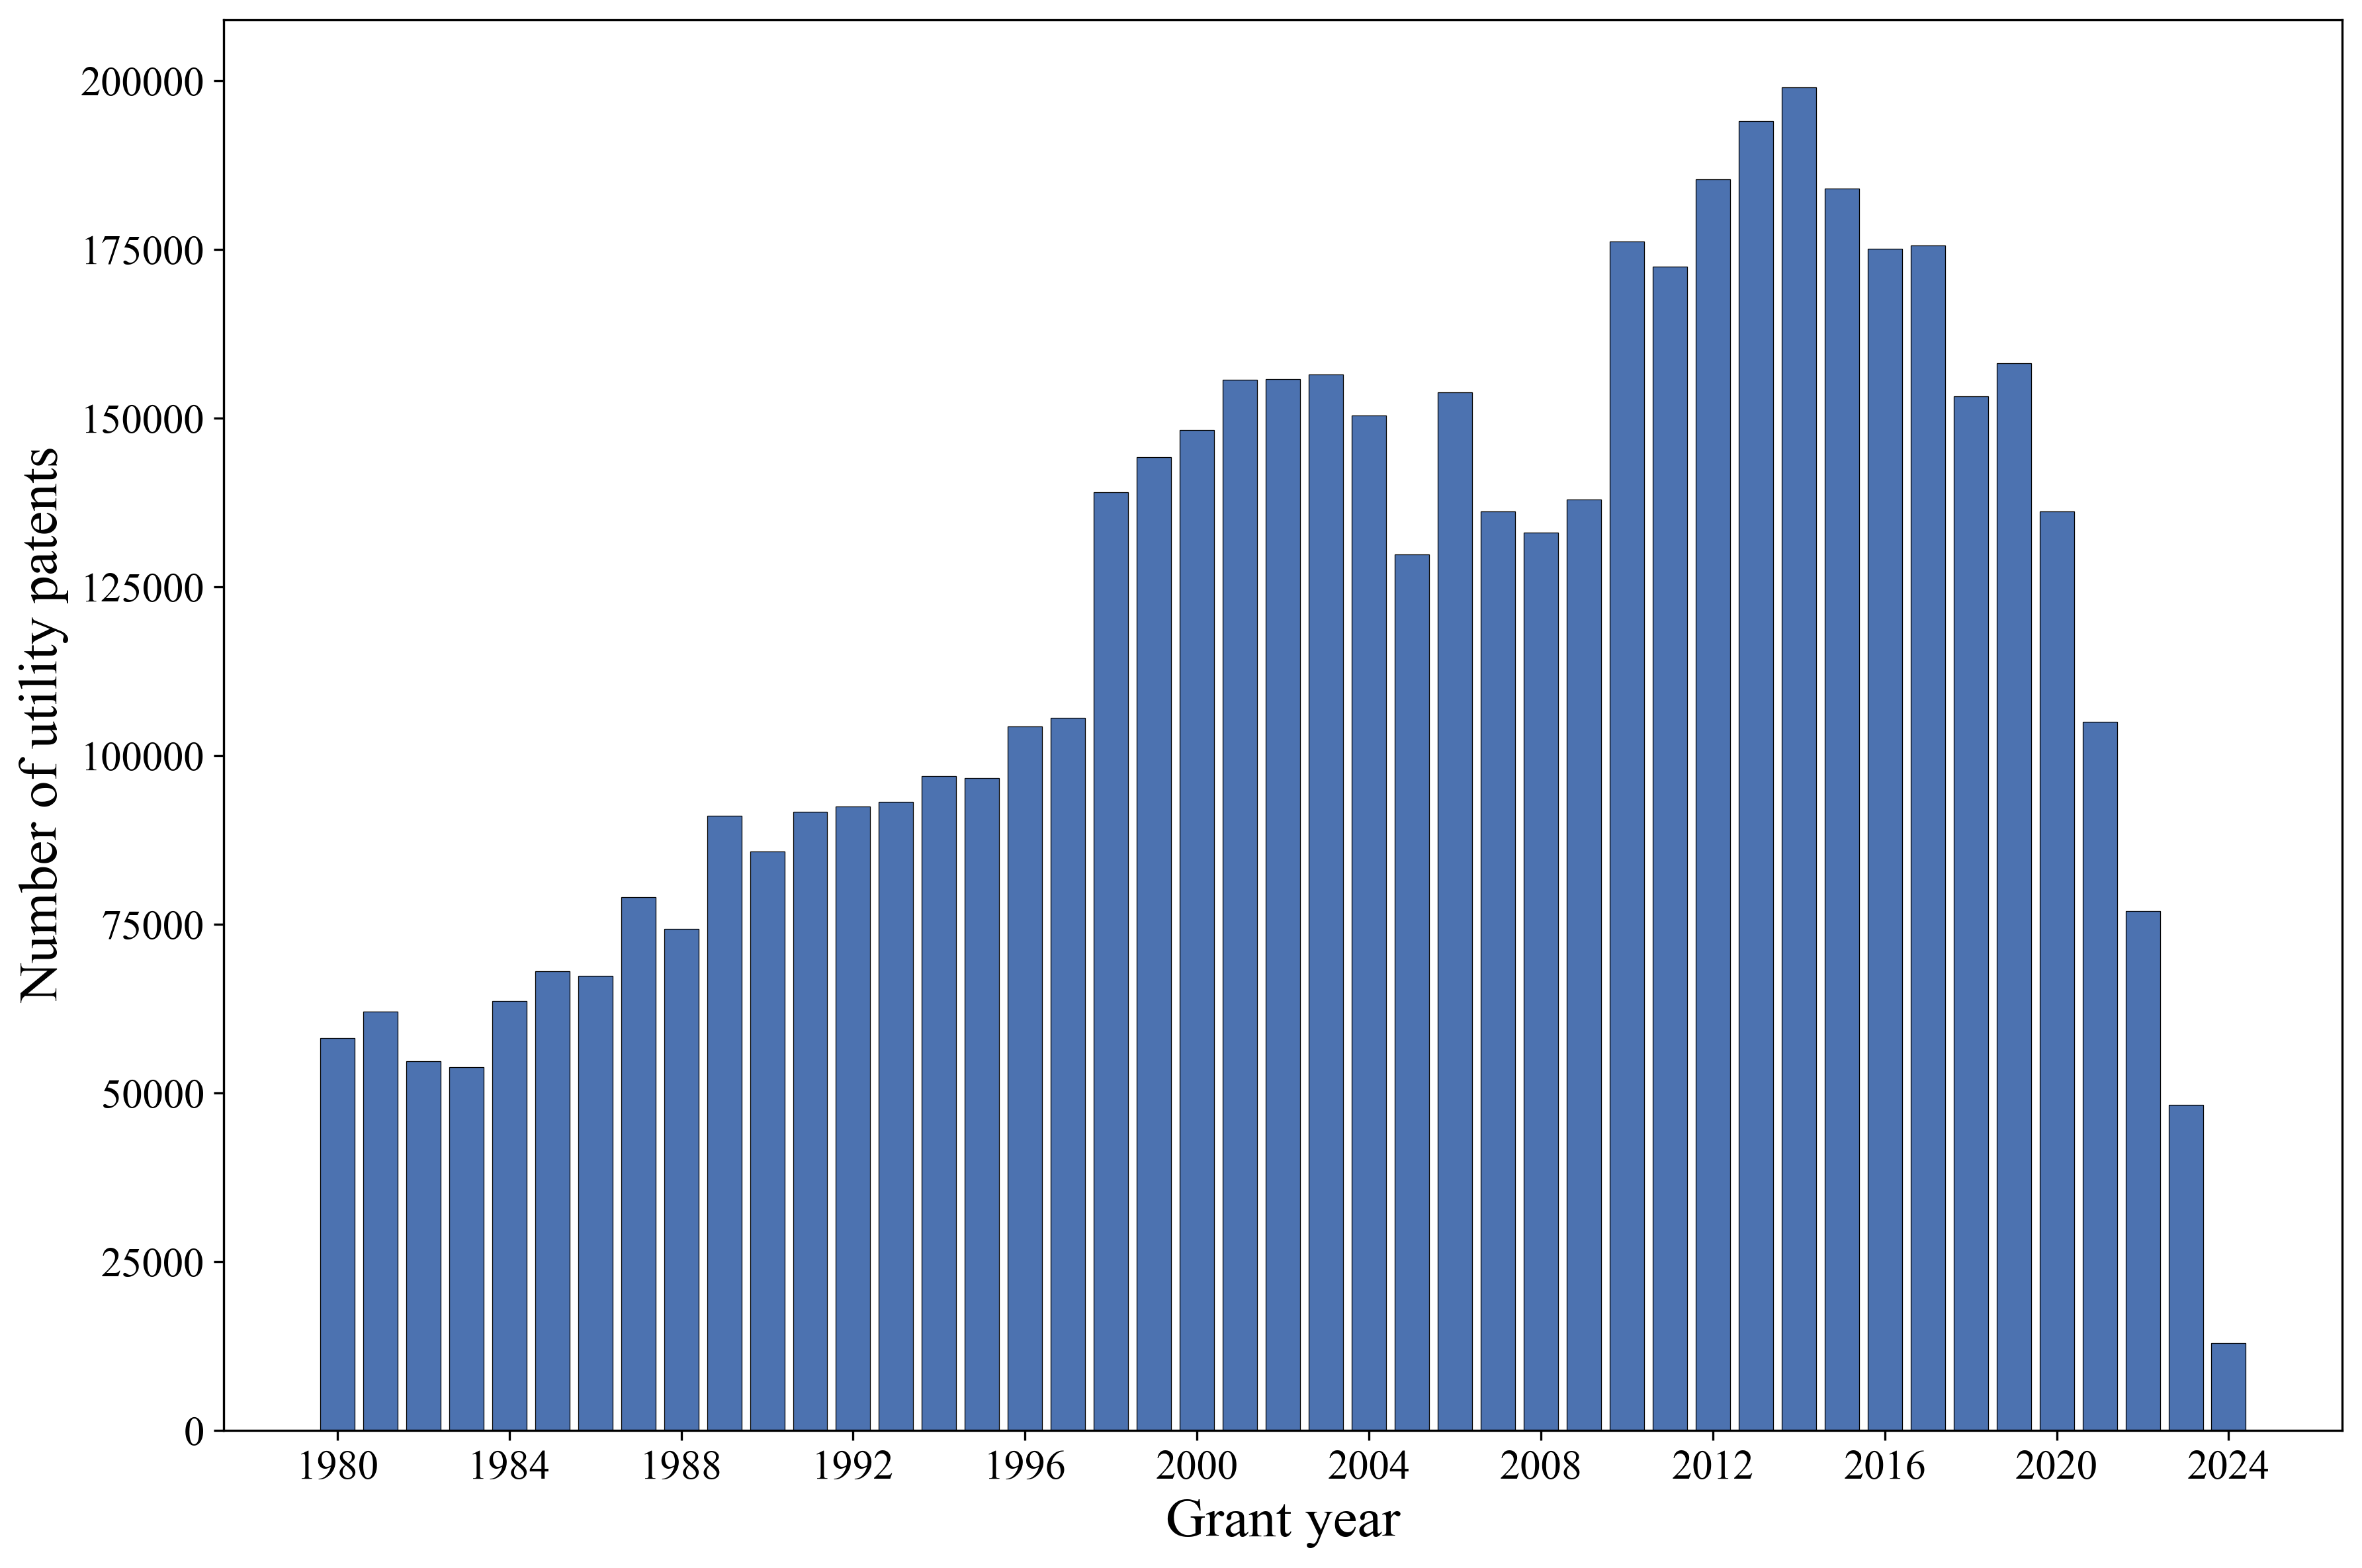

In [13]:
# 1. 过滤：patent_year < 2019
df_use = d_index_df_merged[
    (d_index_df_merged['patent_year'] >= 1980) &
    (d_index_df_merged['patent_year'] < 2025)
]

# ------------------------------------------------------------------
# 3. 统计每年专利数量
# ------------------------------------------------------------------
year_counts = (
    df_use.groupby('patent_year')
          .size()
          .sort_index()
)

# ------------------------------------------------------------------
# 4. 画柱状图
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8),dpi=300)
ax.bar(year_counts.index, year_counts.values, color='#4c72b0', edgecolor='k', linewidth=0.3)
ax.set_xlabel('Grant year')
ax.set_ylabel('Number of utility patents')
ax.set_xticks(range(1980, 2025, 4))   # 每 5 年一个刻度
ax.set_xticklabels(range(1980, 2025, 4))
plt.tight_layout()
plt.show()

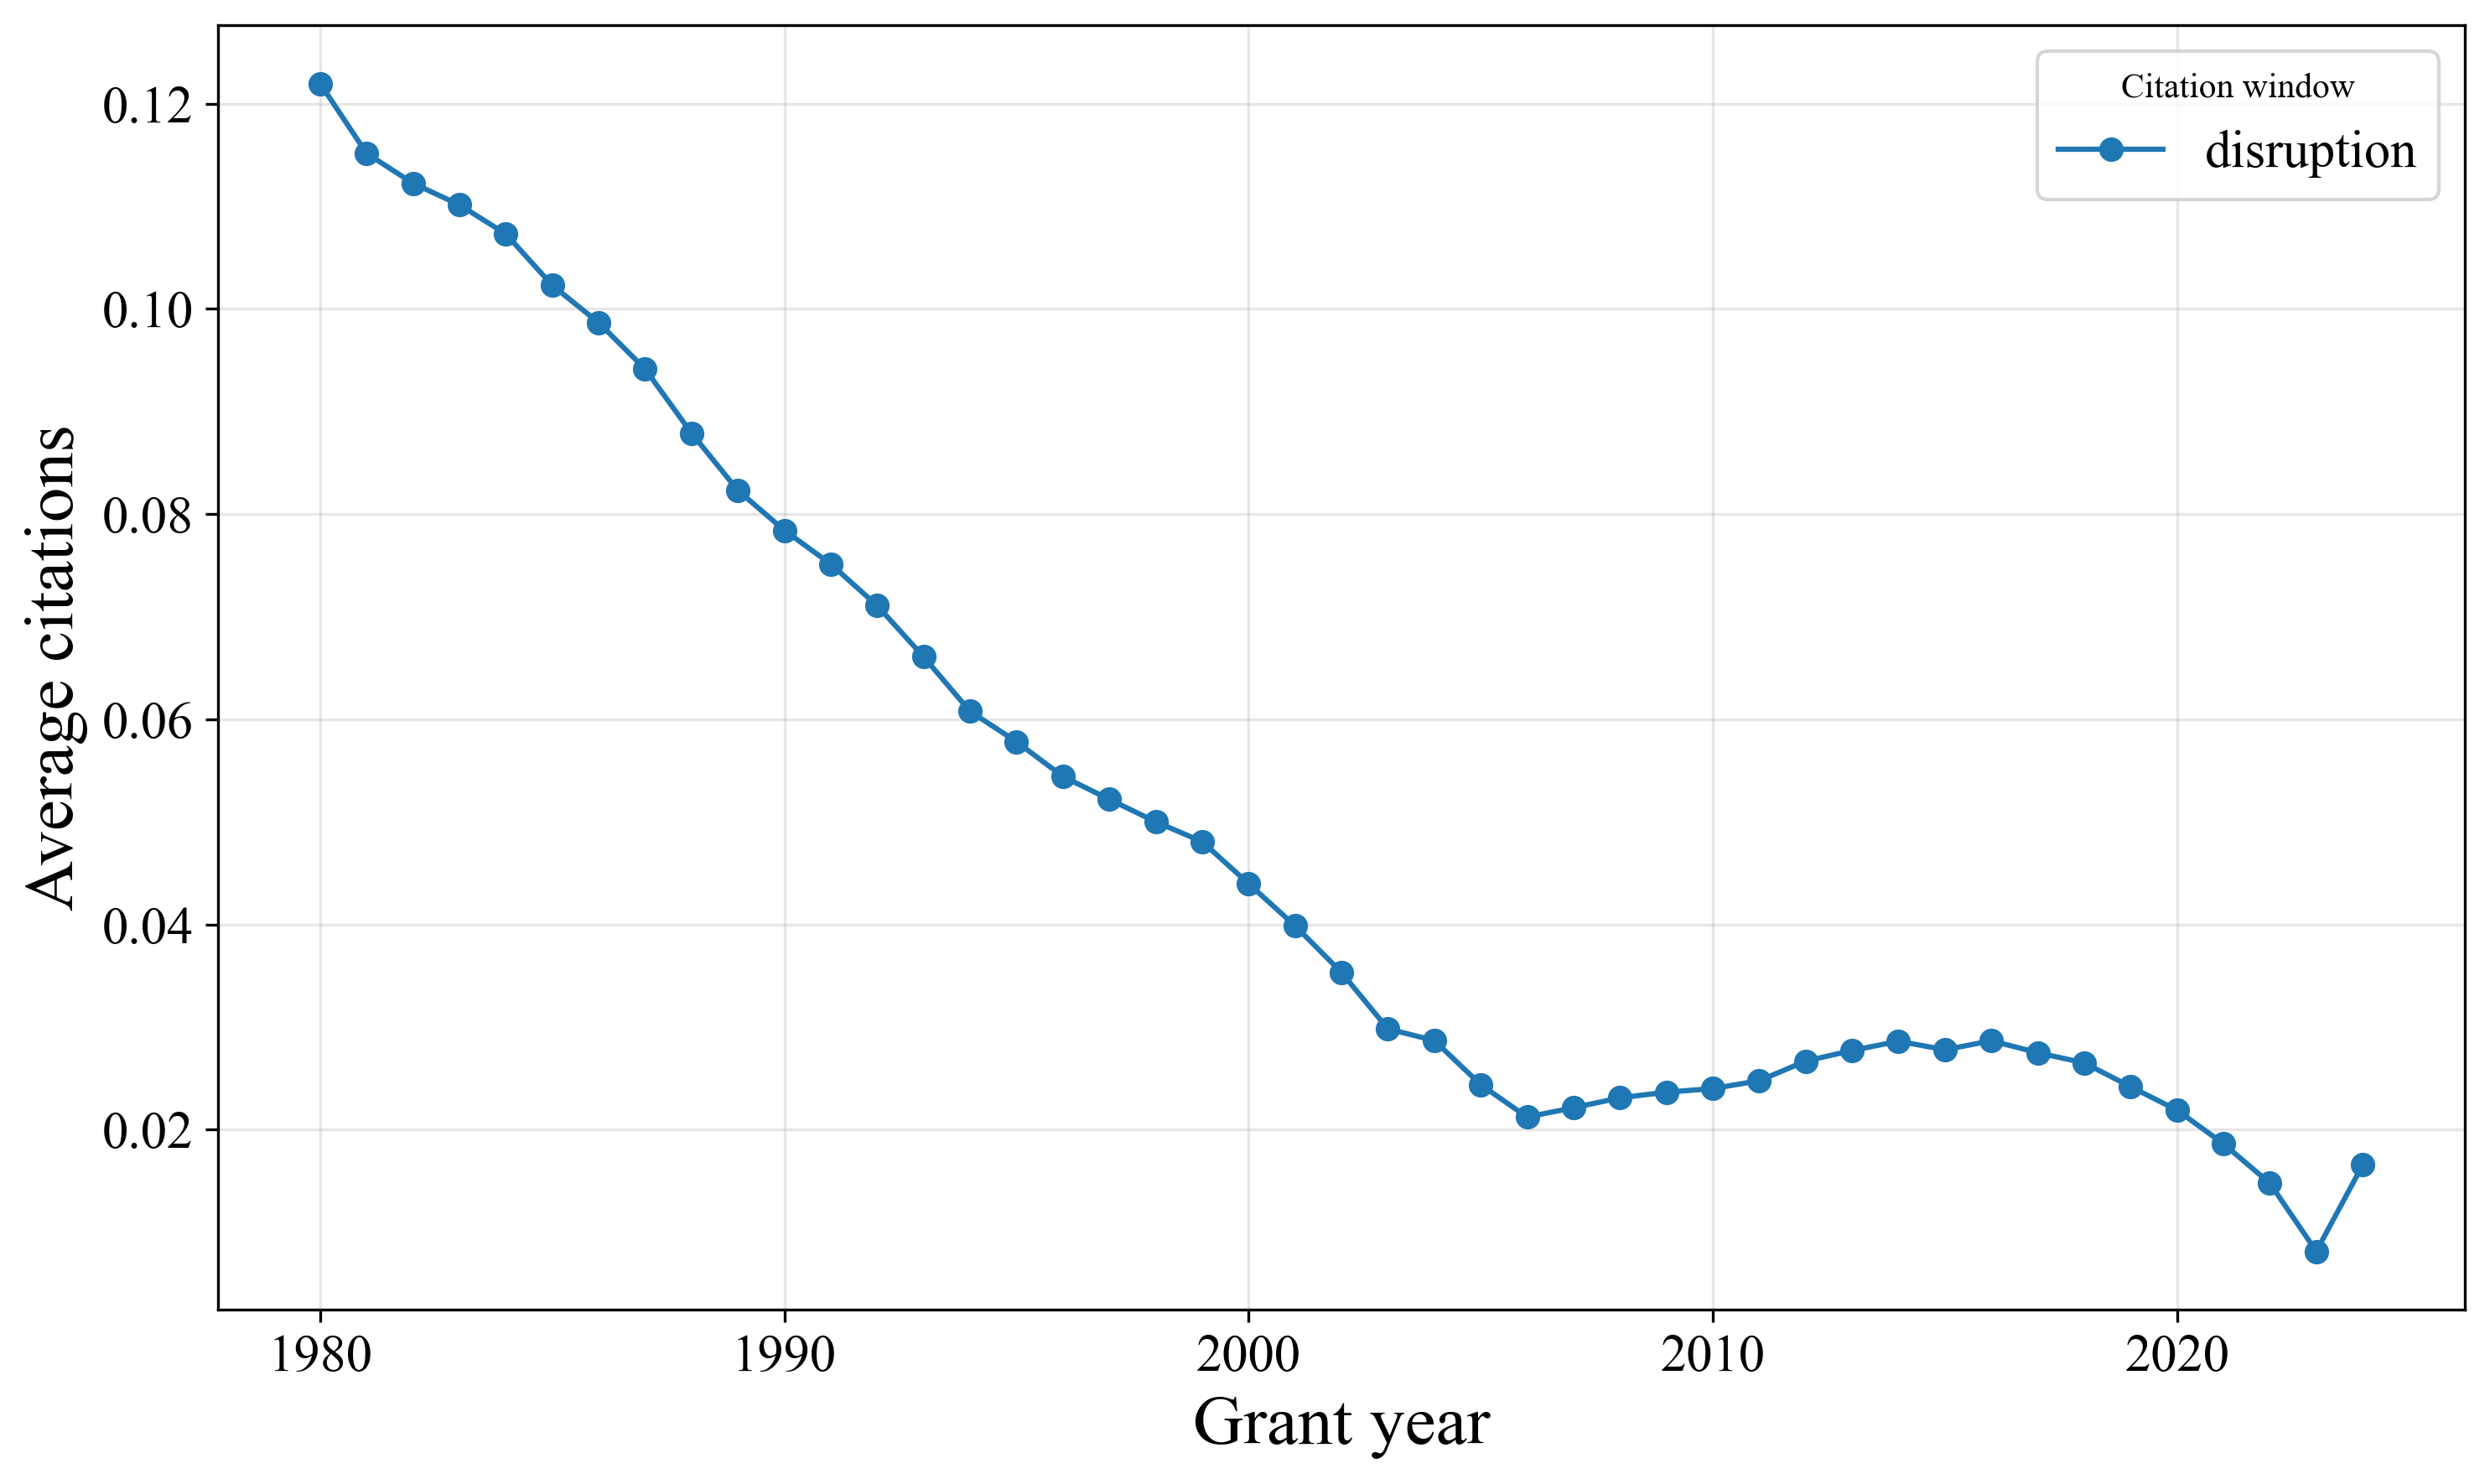

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


# 1. 过滤：patent_year < 2019
df_use = d_index_df_merged[
    (d_index_df_merged['patent_year'] >= 1980) &
    (d_index_df_merged['patent_year'] < 2025)
]

# 2. 按授权年份分组，计算各列均值
yearly = (
    df_use.groupby('patent_year')['d_index']
          .mean()
          .sort_index()
)

# 3. 画图
plt.figure(figsize=(10, 6),dpi=300)

plt.plot(yearly.index, yearly.values, marker='o', label='disruption')

# plt.title('Average forward citations of utility patents by citation window (1980–2018)', fontsize=13)
plt.xlabel('Grant year')
plt.ylabel('Average citations')
plt.legend(title='Citation window')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### Step 3.5 每年前10%颠覆性专利

In [17]:
# 1. 计算每年 95% 分位数
# ----------------------------------------------------------
pdi95 = (
    df_use.groupby('patent_year')['d_index']
          .quantile(0.95)
          .rename('pdi95')
)

In [19]:
pdi95

patent_year
1980    0.500000
1981    0.500000
1982    0.487805
1983    0.489269
1984    0.479474
1985    0.461538
1986    0.454545
1987    0.441860
1988    0.428571
1989    0.413793
1990    0.401100
1991    0.392857
1992    0.382979
1993    0.366667
1994    0.348195
1995    0.333333
1996    0.323251
1997    0.315789
1998    0.306714
1999    0.295481
2000    0.276786
2001    0.259740
2002    0.239197
2003    0.210526
2004    0.200000
2005    0.177497
2006    0.158416
2007    0.165563
2008    0.166667
2009    0.166667
2010    0.166667
2011    0.173913
2012    0.187500
2013    0.200000
2014    0.200000
2015    0.200000
2016    0.210172
2017    0.200000
2018    0.201090
2019    0.200000
2020    0.200000
2021    0.181818
2022    0.166667
2023    0.162647
2024    0.200000
Name: pdi95, dtype: float64

In [20]:
# 2. 合并分位数并筛选
# ----------------------------------------------------------
df_di = (
    df_use.merge(pdi95, left_on='patent_year', right_index=True)
          .query("d_index >= pdi95")
          .drop(columns='pdi95')   # 如不需要可保留
          .sort_values(['patent_year', 'd_index'], ascending=[True, False])
          .reset_index(drop=True)
)

In [21]:
df_di

,patent_id,d_index,patent_year,num_claims,patent_type
0,4213562,0.999305,1980,22,utility
1,4196265,0.991826,1980,18,utility
2,4199781,0.991736,1980,12,utility
3,4206500,0.980392,1980,6,utility
4,4228724,0.978355,1980,25,utility
...,...,...,...,...,...
270483,12126640,0.200000,2024,18,utility
270484,12130847,0.200000,2024,22,utility
270485,12137483,0.200000,2024,20,utility
270486,12154047,0.200000,2024,20,utility


In [22]:
df_di['patent_id'] = df_di['patent_id'].astype('str')

#### Step 4 分析语义

In [23]:
p2psim = pd.read_csv('../result/p2p_reference.sim.csv')
p2psim.head()

KeyboardInterrupt: 

In [20]:
p2psim = p2psim.rename(columns={
    'citing_patent_id': 'cited_id',
    'cited_patent_id' : 'citing_id',
    'similarity'      : 'sim',
    'category'        : 'cited_by'
})

In [21]:
p2psim['cited_id'] = p2psim['cited_id'].astype('str')
p2psim['citing_id'] = p2psim['citing_id'].astype('str')

In [22]:
p2psim

,cited_id,citing_id,sim,cited_by
0,5093563,10000000,0.619,cited by examiner
1,5751830,10000000,0.675,cited by applicant
2,7804268,10000001,0.695,cited by examiner
3,9022767,10000001,0.788,cited by examiner
4,9090016,10000001,0.673,cited by examiner
...,...,...,...,...
112701078,9787457,RE50356,0.583,cited by examiner
112701079,10164689,RE50356,0.664,cited by examiner
112701080,10652955,RE50356,1.000,cited by applicant
112701081,8431969,RE50357,0.811,cited by applicant


In [23]:
p2psim = (
    p2psim
    .merge(
        d_index_df_merged[['patent_id', 'patent_year','num_claims','cites_5yr']],
        left_on='citing_id',          # 被引专利
        right_on='patent_id',             # df_application 的专利
        how='left'                       
    )
)

In [24]:
p2psim.dropna(subset=['cites_5yr'],inplace=True)

In [25]:
p2psim

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,20.0,11.0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,20.0,11.0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,12.0,0.0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,12.0,0.0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,12.0,0.0
...,...,...,...,...,...,...,...,...
112275799,4185894,RE34947,0.612,NaN,RE34947,1995.0,13.0,0.0
112275800,4368386,RE34947,0.590,NaN,RE34947,1995.0,13.0,0.0
112275801,4481531,RE34947,0.533,NaN,RE34947,1995.0,13.0,0.0
112275802,4920417,RE34947,0.822,NaN,RE34947,1995.0,13.0,0.0


In [26]:
p2psim_top = p2psim.assign(
    is_top=p2psim['cited_id'].isin(df_top1pct['patent_id']).astype(int)
)

In [27]:
p2psim_top = p2psim_top[(p2psim_top['sim'] < 0.999)]
p2psim_top

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,is_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,20.0,11.0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,20.0,11.0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,12.0,0.0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,12.0,0.0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,12.0,0.0,0
...,...,...,...,...,...,...,...,...,...
112275799,4185894,RE34947,0.612,NaN,RE34947,1995.0,13.0,0.0,0
112275800,4368386,RE34947,0.590,NaN,RE34947,1995.0,13.0,0.0,0
112275801,4481531,RE34947,0.533,NaN,RE34947,1995.0,13.0,0.0,0
112275802,4920417,RE34947,0.822,NaN,RE34947,1995.0,13.0,0.0,0


In [37]:
# 保存
p2psim_top.to_csv('./citations_result/p2psim_top.csv',index=False)

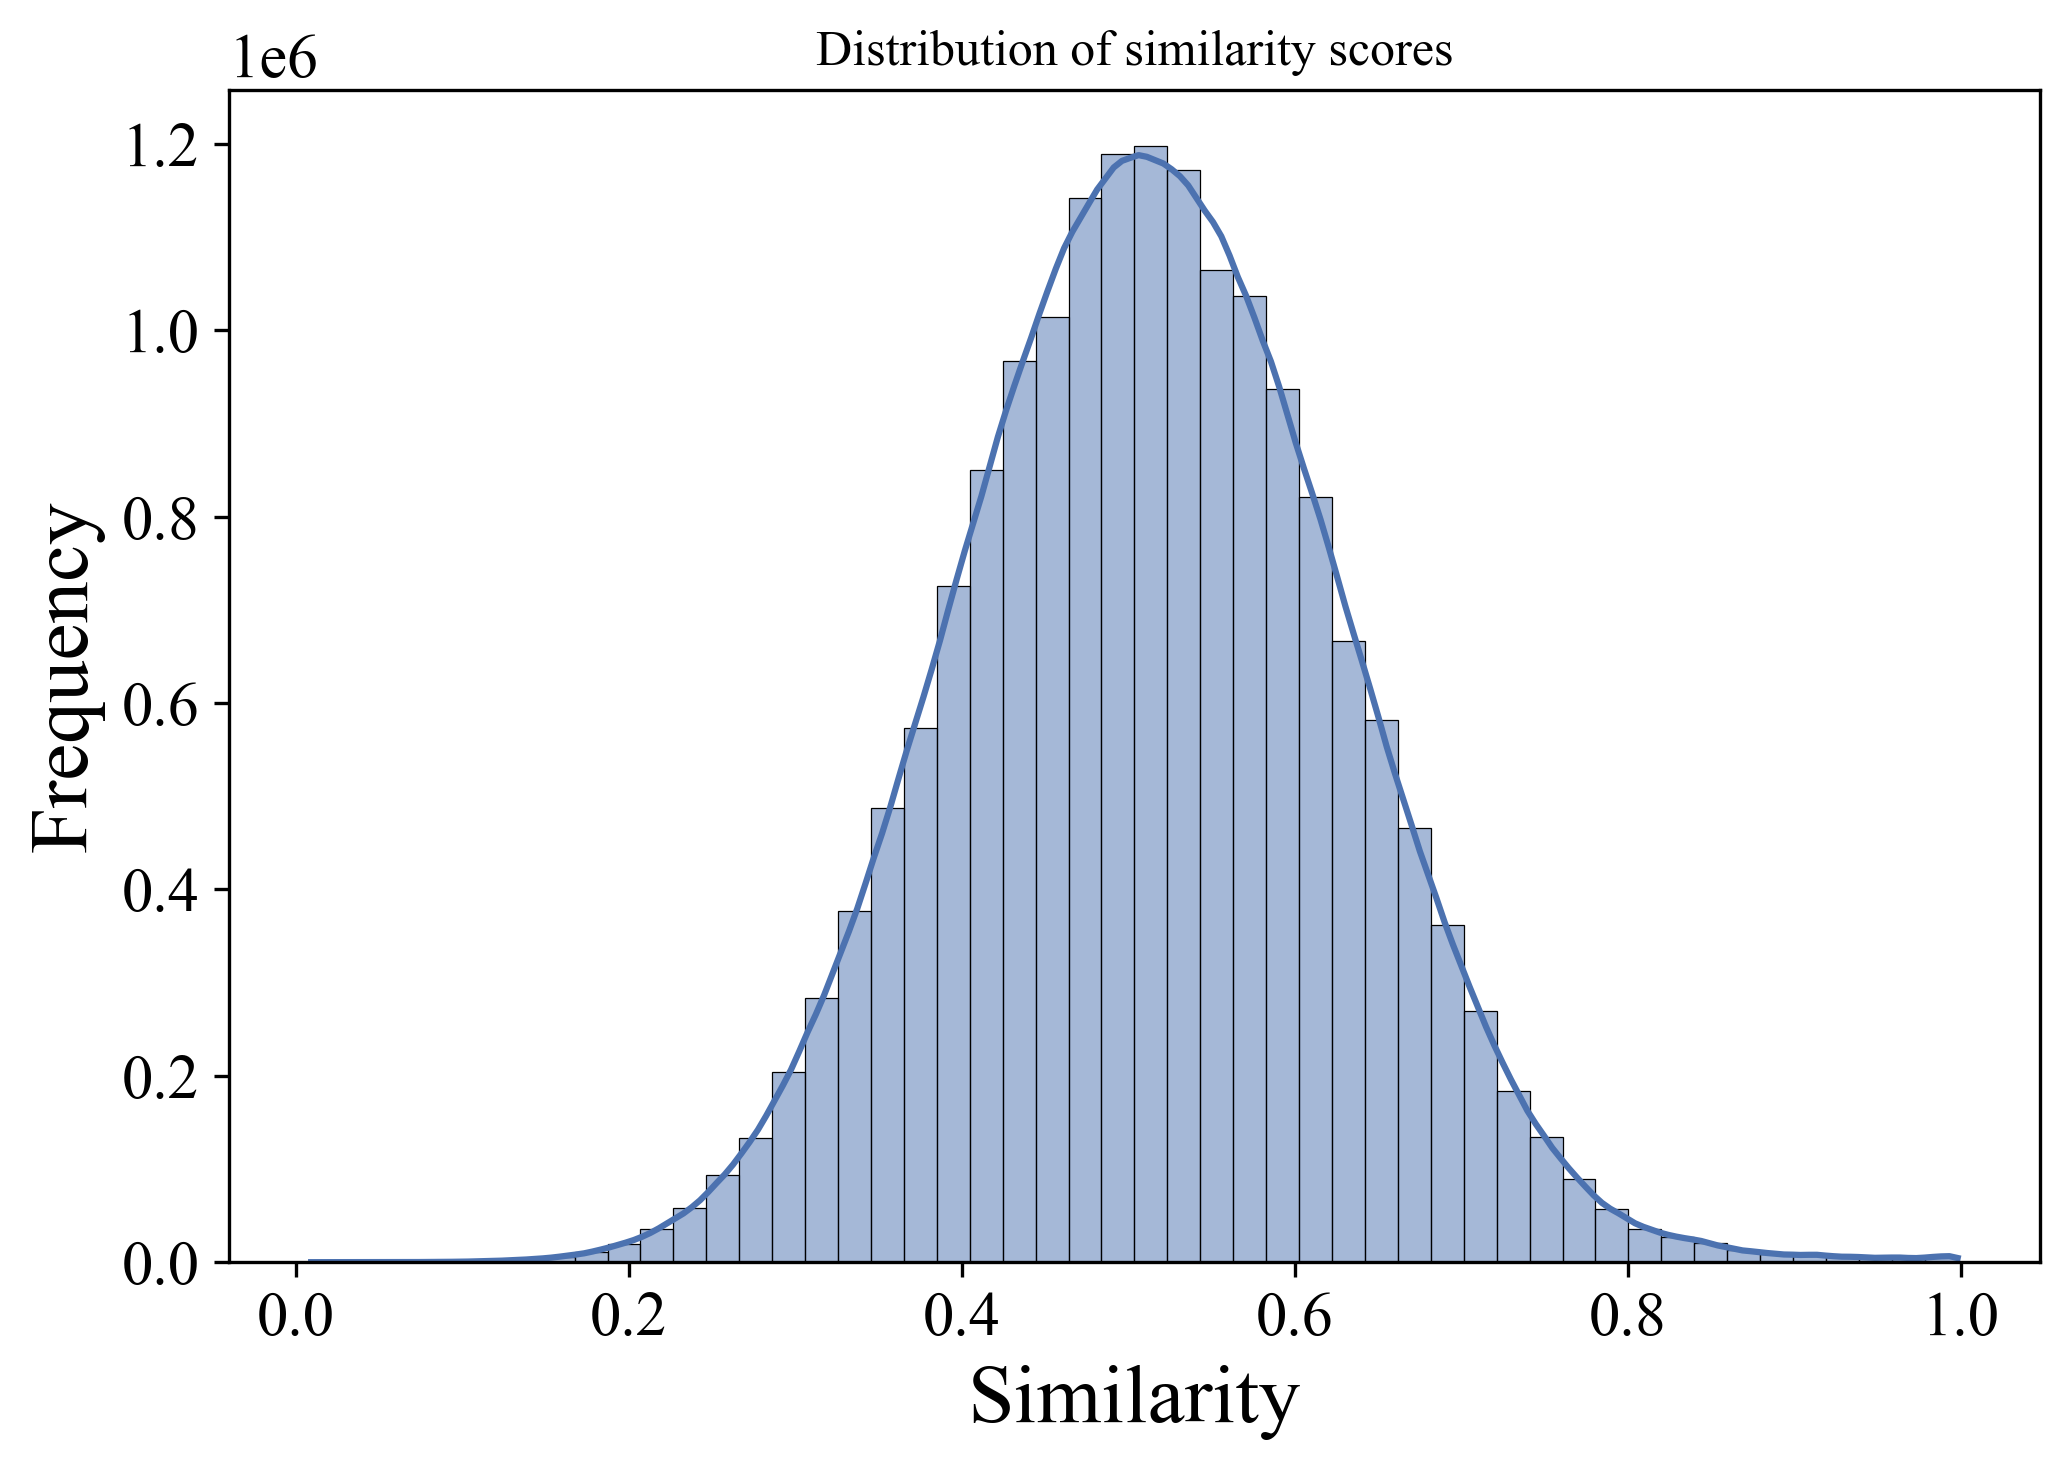

In [36]:
import seaborn as sns

plt.figure(figsize=(7,5),dpi=300)
sns.histplot(p2psim_top['sim'], bins=50, kde=True, color='#4c72b0', edgecolor='k', lw=0.3)
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of similarity scores')
plt.tight_layout()
plt.show()

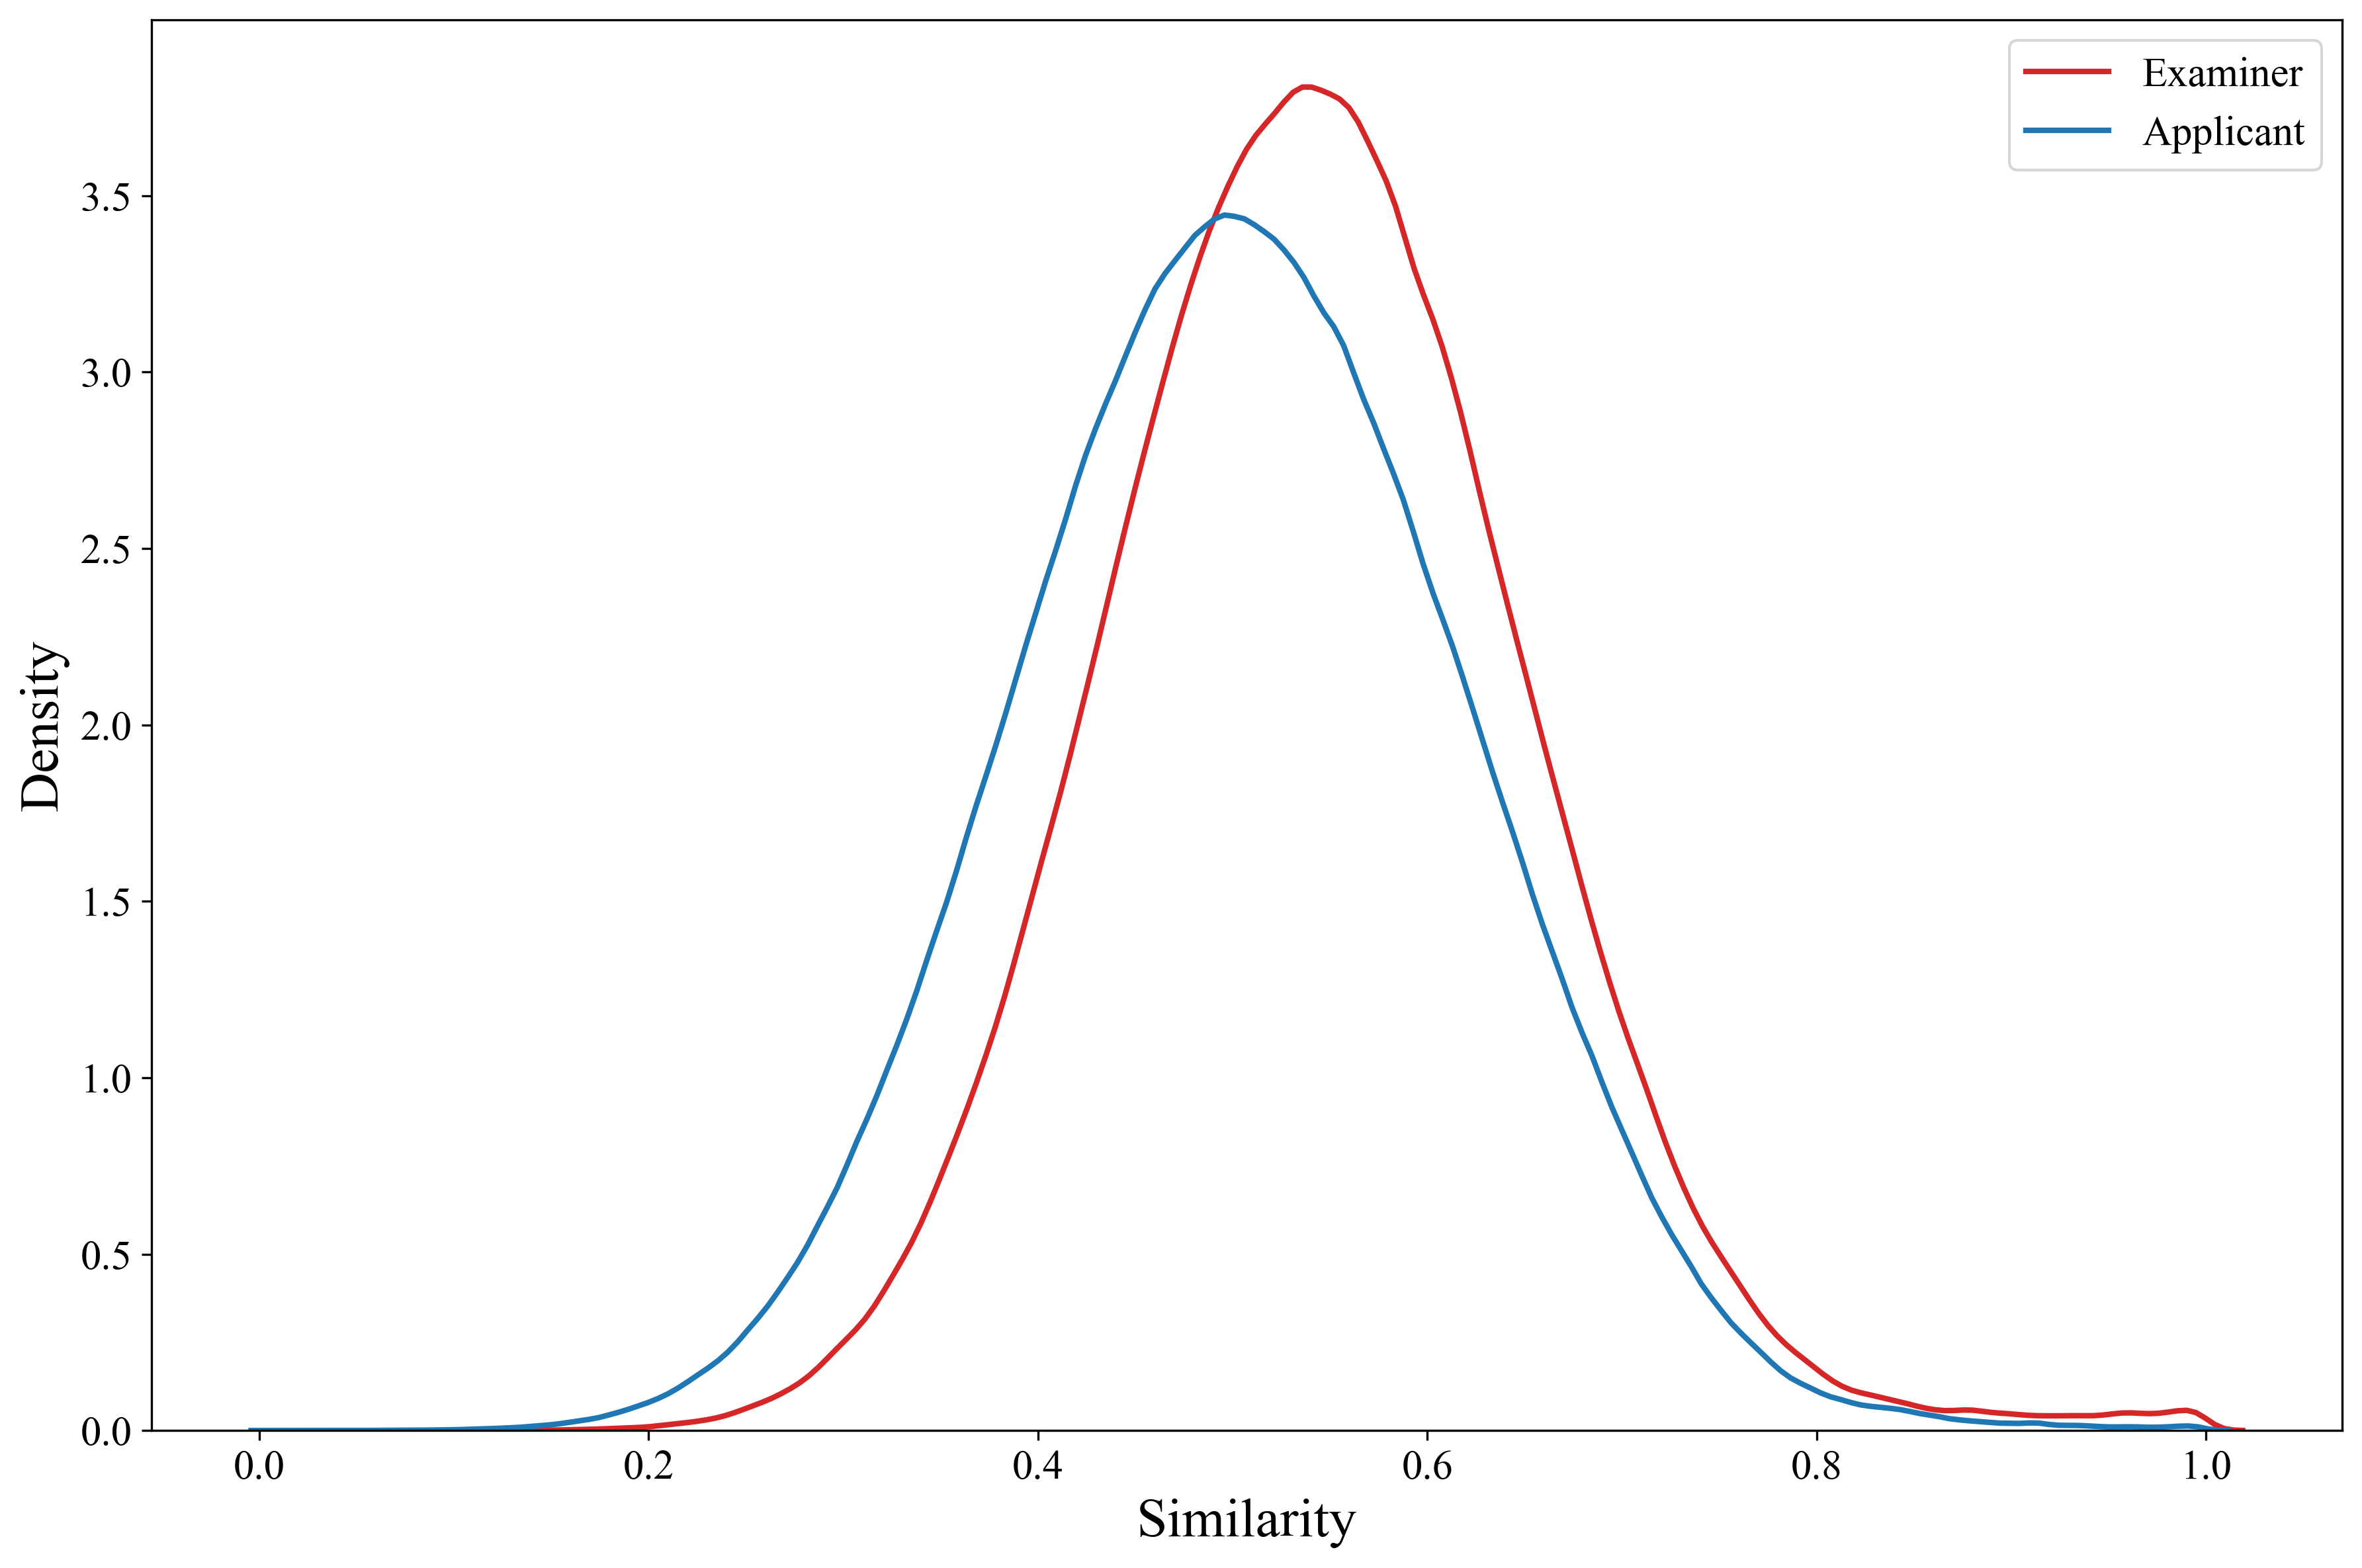

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 先确保 category 列干净
p2psim_top['cited_by'] = p2psim_top['cited_by'].str.lower().str.strip()

# ------------------------------------------------------------
# 一次性画两组 KDE（密度曲线），不画直方图以便更干净
# ------------------------------------------------------------
plt.figure(figsize=(12, 8), dpi=300)

sns.kdeplot(
    data=p2psim_top[p2psim_top['cited_by'] == 'cited by examiner'],
    x='sim',
    label='Examiner',
    color='#d62728',   # 红色
    linewidth=2
)

sns.kdeplot(
    data=p2psim_top[p2psim_top['cited_by'] == 'cited by applicant'],
    x='sim',
    label='Applicant',
    color='#1f77b4',   # 蓝色
    linewidth=2
)

plt.xlabel('Similarity')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
p2psim_top.to_csv('./p2psim_top.csv',index=False)

#### Step 5 直接加载p2psim_top

In [24]:
p2psim_top = pd.read_csv('./citations_result/p2psim_top.csv')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15220\3877586799.py:1: DtypeWarning: Columns (0,1,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  p2psim_top = pd.read_csv('./citations_result/p2psim_top.csv')


In [25]:
p2psim_di_top = p2psim_top.assign(
    is_di_top=p2psim_top['cited_id'].isin(df_di['patent_id']).astype(int)
)

In [26]:
p2psim_di_top.head()

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,is_top,is_di_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,20.0,11.0,0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,20.0,11.0,0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,12.0,0.0,0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,12.0,0.0,0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,12.0,0.0,0,0


##### 引用普通专利和top专利的相似度变化趋势

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) 按 is_top 分组，取每年平均 similarity
year_sim = (
    p2psim_di_top
    .query("1981 <= patent_year <= 2024")
    .assign(group=lambda x: np.where(x['is_di_top'] == 0, 'non-top', 'top'))
    .groupby(['patent_year', 'group'])['sim']
    .mean()
    .unstack('group')          # pivot 成列
    .sort_index()
)


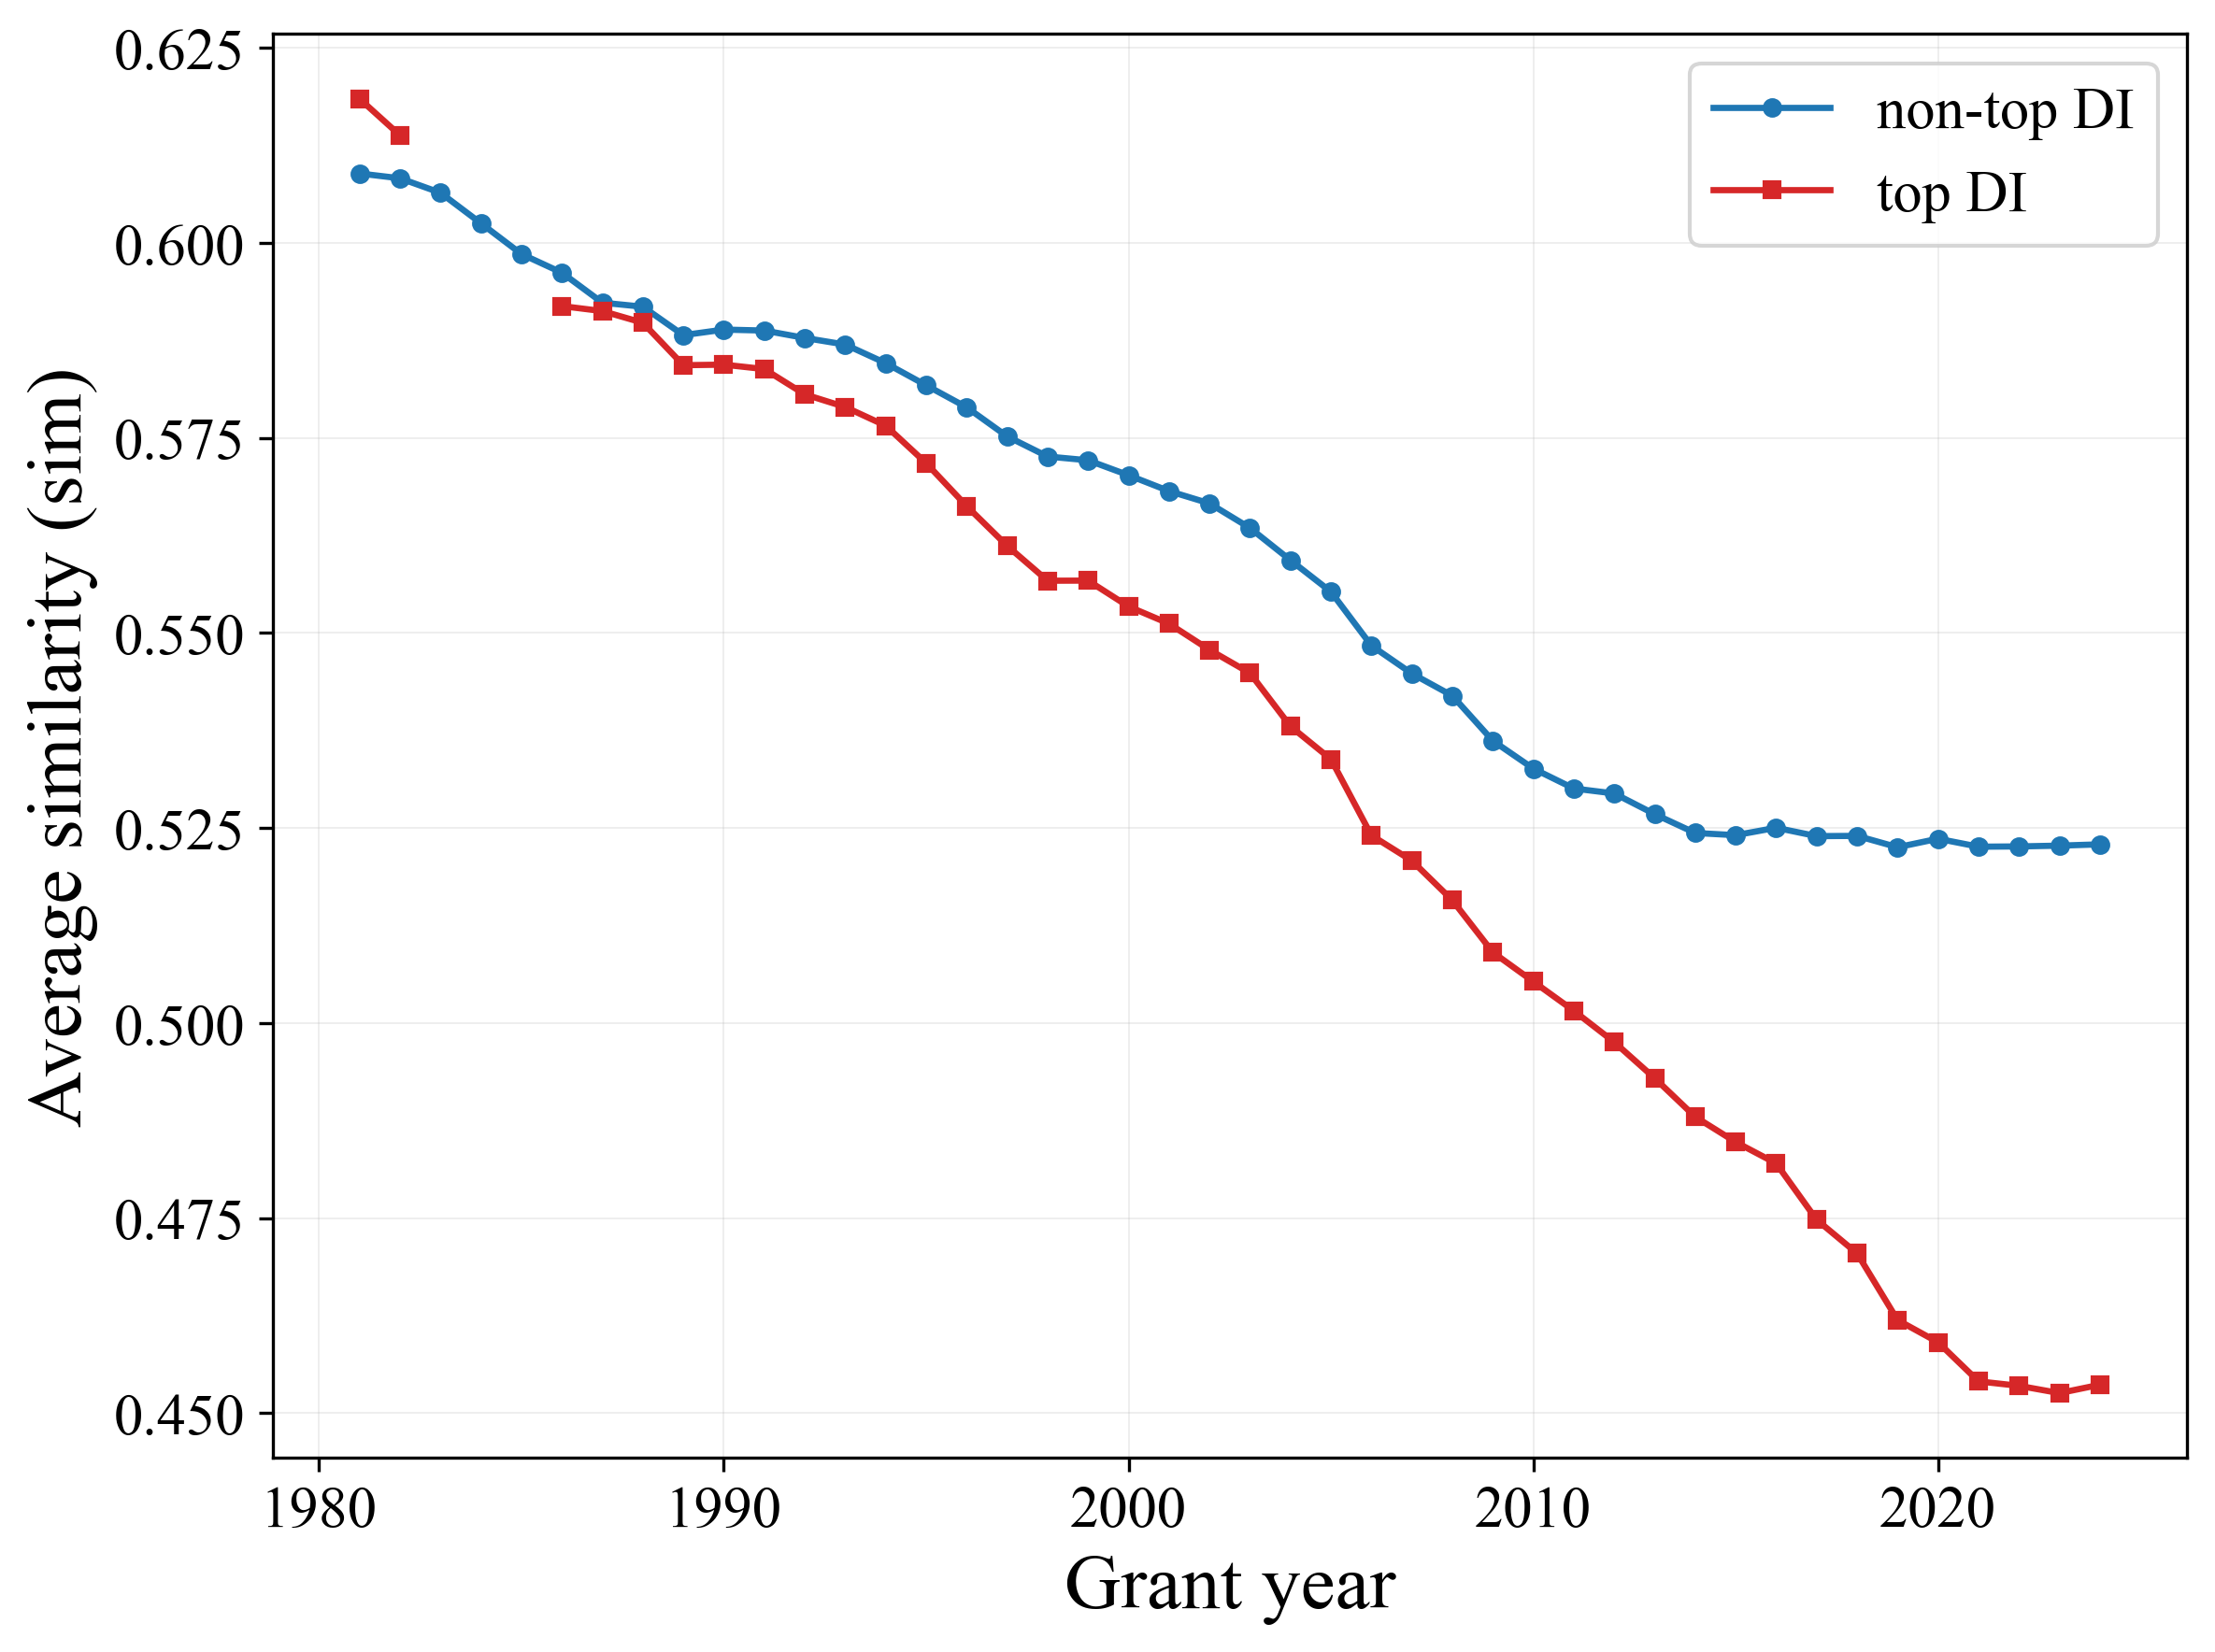

In [32]:
# 2) 绘图
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

for col, color, marker in [('non-top', '#1f77b4', 'o'),
                           ('top',     '#d62728', 's')]:
    ax.plot(year_sim.index, year_sim[col],
            color=color, marker=marker,
            lw=1.6, ms=4, label=col + ' DI')

ax.set_xlabel('Grant year')
ax.set_ylabel('Average similarity (sim)')
ax.grid(alpha=0.25, lw=0.4)
ax.legend(frameon=True, fancybox=True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [33]:
# 1) 先对 sim 做聚合
sim_stats = (
    p2psim_top
    .groupby('citing_id')['sim']
    .agg(['max', 'min','mean', 'std'])
    .rename(columns={'max': 'sim_max',
                    'min':'sim_min',
                     'mean': 'sim_mean',
                     'std': 'sim_std',})
    .assign(sim_cv=lambda x: x['sim_std'] / x['sim_mean'])
)

In [34]:
sim_stats

,sim_max,sim_min,sim_mean,sim_std,sim_cv
citing_id,,,,,
4180867,0.453,0.453,0.453000,NaN,NaN
4180868,0.598,0.554,0.571667,0.023245,0.040662
4180870,0.462,0.462,0.462000,NaN,NaN
4180871,0.694,0.548,0.615667,0.073582,0.119516
4180875,0.680,0.653,0.670000,0.014799,0.022088
...,...,...,...,...,...
RE31699,0.726,0.557,0.637667,0.084760,0.132923
RE31700,0.647,0.647,0.647000,NaN,NaN
RE31701,0.733,0.733,0.733000,NaN,NaN


In [36]:
p2psim_di_top

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,is_top,is_di_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,20.0,11.0,0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,20.0,11.0,0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,12.0,0.0,0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,12.0,0.0,0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,12.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
111617299,4185894,RE34947,0.612,NaN,RE34947,1995.0,13.0,0.0,0,0
111617300,4368386,RE34947,0.590,NaN,RE34947,1995.0,13.0,0.0,0,0
111617301,4481531,RE34947,0.533,NaN,RE34947,1995.0,13.0,0.0,0,0
111617302,4920417,RE34947,0.822,NaN,RE34947,1995.0,13.0,0.0,0,0


In [37]:
# 按 citing_id 分组，把 is_top 求和，并重置索引
citing_top_di = (
    p2psim_di_top.groupby('citing_id', as_index=False)['is_di_top']
              .sum()
              .rename(columns={'is_di_top': 'top_sum'})
)

In [39]:
citing_top_di['top_sum'].max()

1043

In [42]:
# 如果还想把其它列也保留（例如 patent_year, num_claims 等），
# 可以先取每个 citing_id 的第一行，再合并 top_sum：
other_cols = ['patent_year', 'num_claims', 'cites_5yr']  # 按需增删
summary = (
    p2psim_di_top.drop_duplicates(subset=['citing_id'], keep='first')
              .drop(columns=['is_di_top','is_top'])           # 去掉旧的 is_top
              .merge(citing_top_di, on='citing_id', how='left')
)

In [43]:
summary

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,top_sum
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,20.0,11.0,0
1,7804268,10000001,0.695,cited by examiner,10000001,2018.0,12.0,0.0,0
2,4617207,10000002,0.581,cited by examiner,10000002,2018.0,9.0,0.0,0
3,4342799,10000003,0.571,cited by applicant,10000003,2018.0,18.0,2.0,0
4,5632133,10000004,0.661,cited by examiner,10000004,2018.0,6.0,0.0,0
...,...,...,...,...,...,...,...,...,...
7019525,4005621,RE31699,0.557,NaN,RE31699,1984.0,15.0,0.0,0
7019526,4121599,RE31700,0.647,NaN,RE31700,1984.0,12.0,0.0,0
7019527,4057452,RE31701,0.733,NaN,RE31701,1984.0,52.0,0.0,0
7019528,3980511,RE34357,0.441,NaN,RE34357,1993.0,133.0,0.0,0


In [44]:
# 2) 合并到 summary
summary = summary.merge(sim_stats, on='citing_id', how='left')

In [45]:
summary_top = summary[summary['top_sum']>0]
summary_top

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,top_sum,sim_max,sim_min,sim_mean,sim_std,sim_cv
6,3940227,10000007,0.509,cited by applicant,10000007,2018.0,24.0,9.0,3,0.754,0.296,0.495290,0.092496,0.186752
7,4013259,10000008,0.635,cited by applicant,10000008,2018.0,11.0,0.0,1,0.635,0.482,0.546846,0.046470,0.084978
10,5182056,10000011,0.503,cited by applicant,10000011,2018.0,30.0,6.0,1,0.585,0.321,0.483821,0.065189,0.134737
13,5984247,10000018,0.603,cited by applicant,10000018,2018.0,13.0,1.0,1,0.731,0.568,0.663200,0.073435,0.110728
16,4235277,10000021,0.580,cited by examiner,10000021,2018.0,4.0,0.0,1,0.979,0.538,0.699857,0.165119,0.235932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7019506,6108926,9975736,0.371,cited by examiner,9975736,2018.0,8.0,0.0,3,0.787,0.371,0.601111,0.127514,0.212131
7019513,3966170,9975745,0.593,cited by examiner,9975745,2018.0,8.0,1.0,4,0.651,0.356,0.518947,0.077759,0.149840
7019515,4087895,9975747,0.348,cited by examiner,9975747,2018.0,20.0,1.0,1,0.691,0.348,0.533750,0.107397,0.201213
7019519,4245666,9975751,0.688,cited by applicant,9975751,2018.0,10.0,0.0,1,0.737,0.420,0.579389,0.082541,0.142463


##### 整体相似度变化

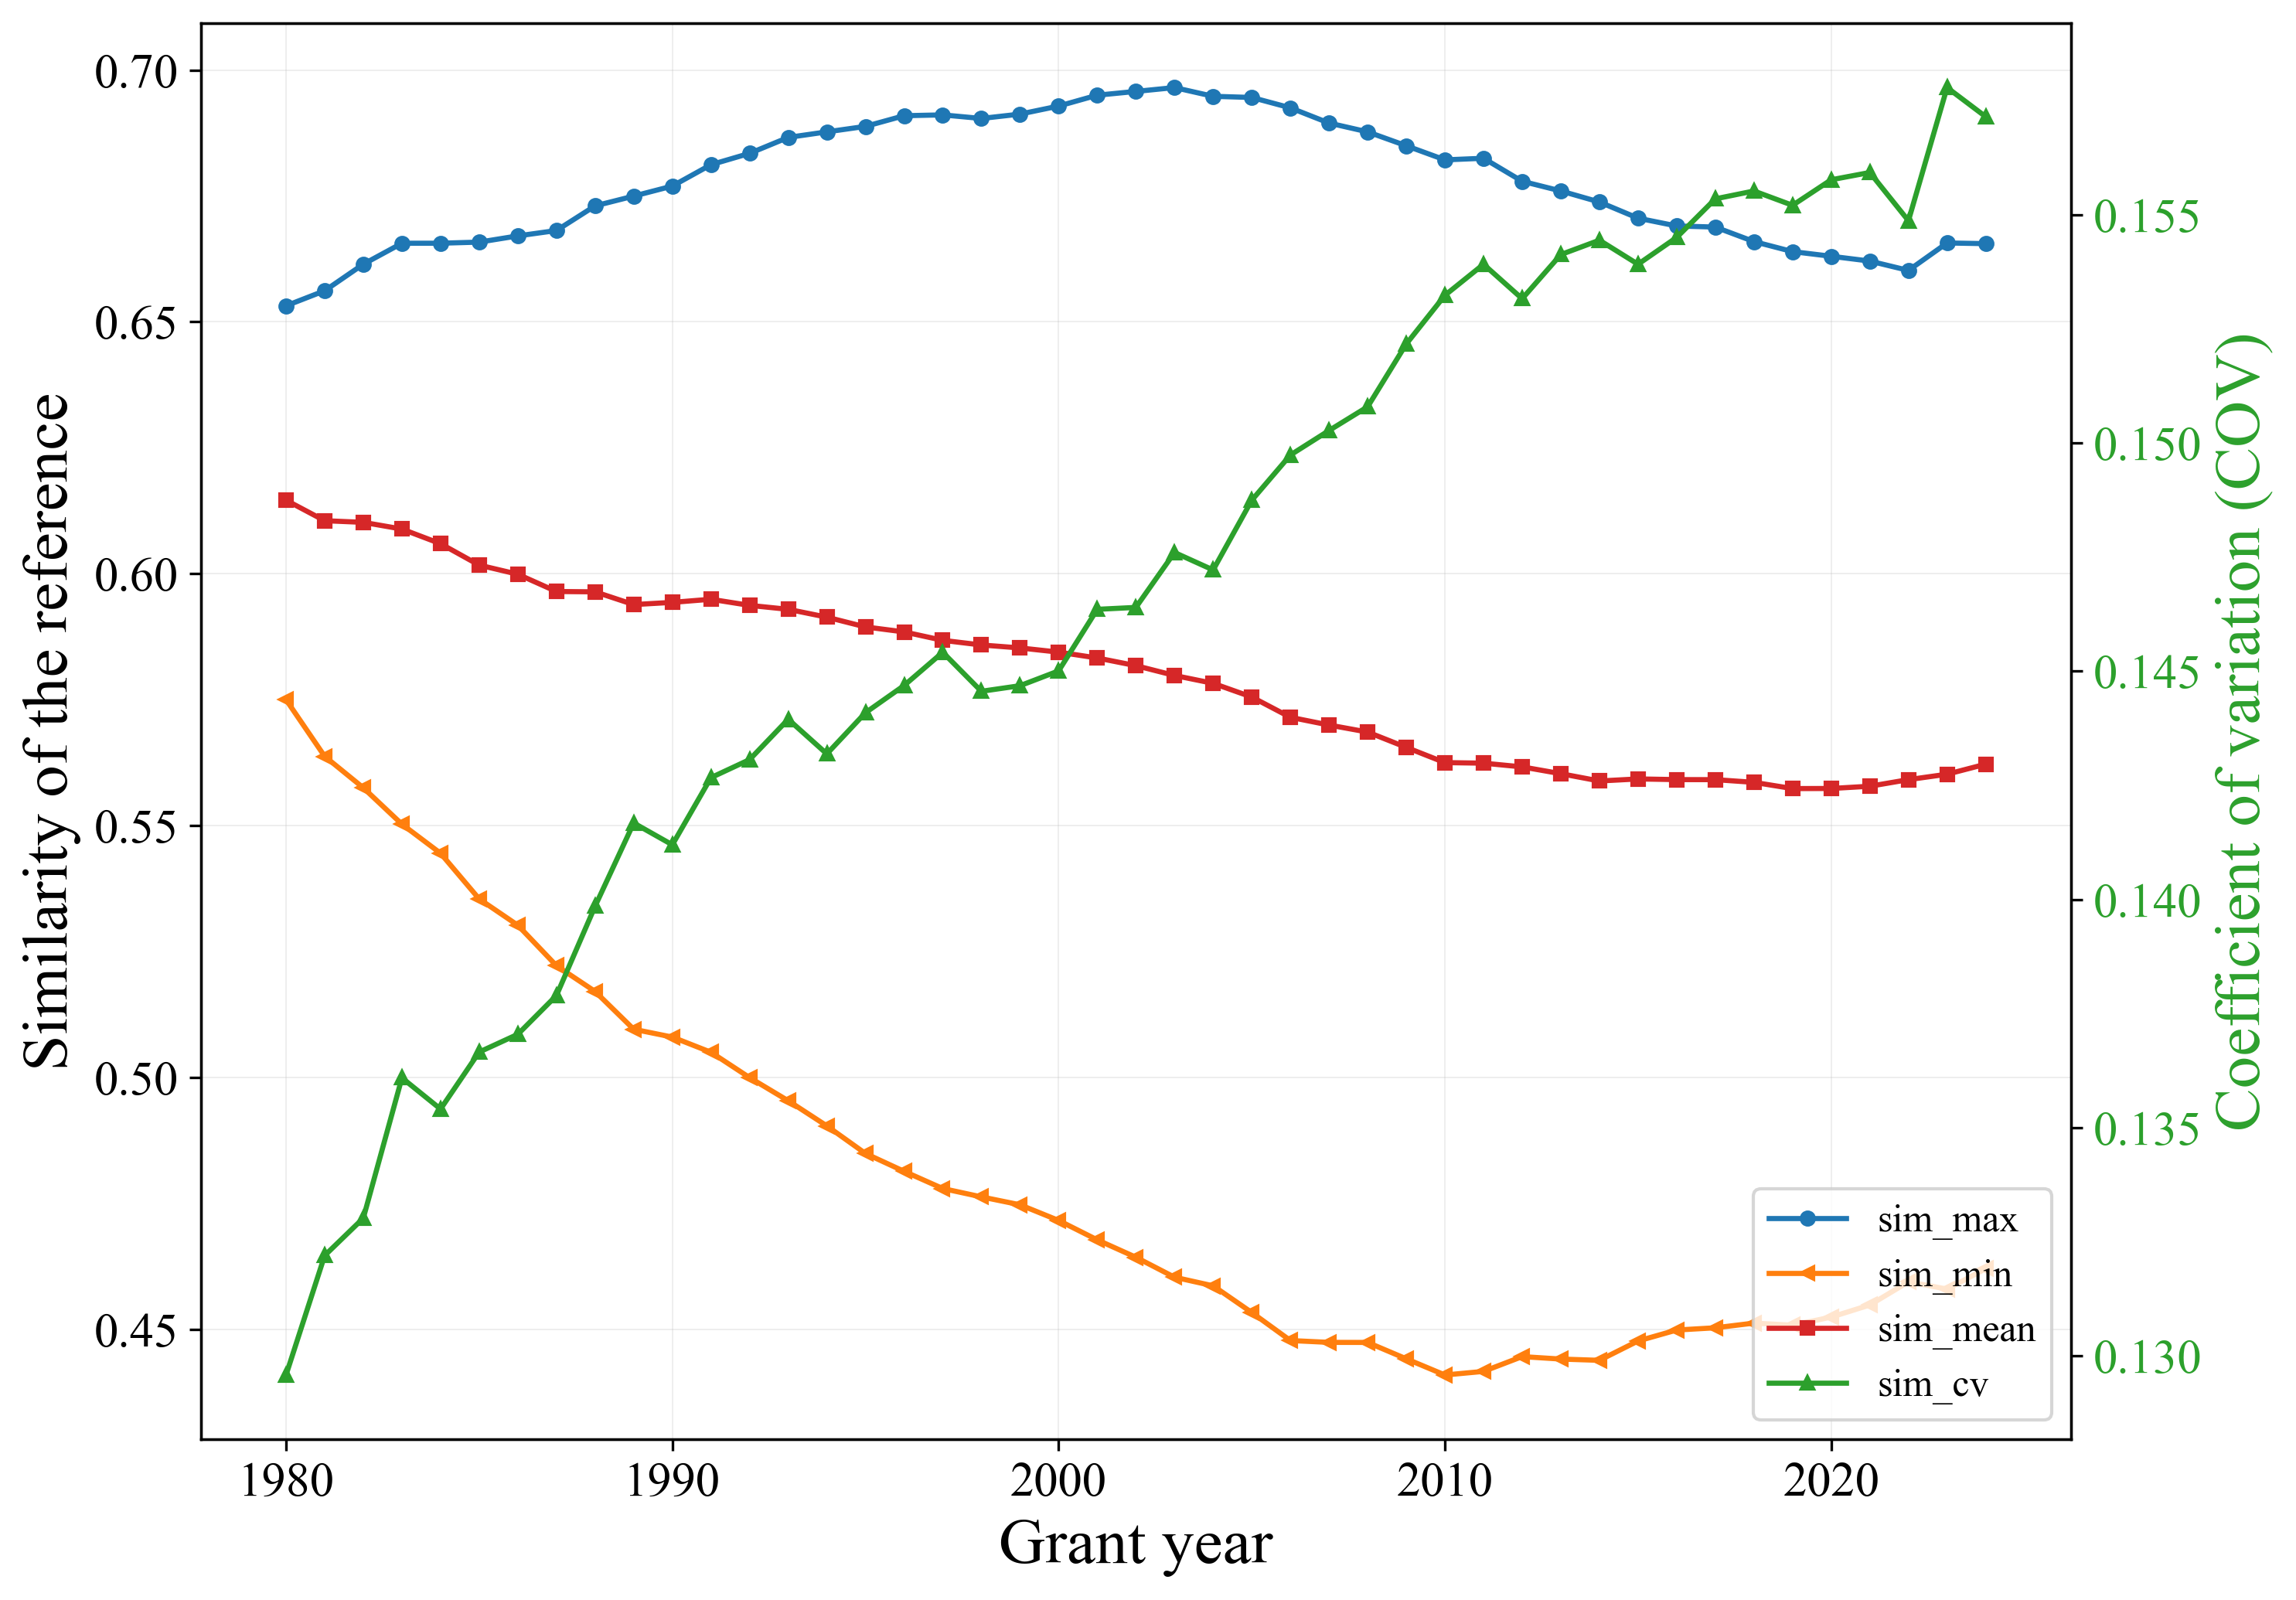

In [46]:
# 1) 数据准备（保持不变）
cols = ['sim_max', 'sim_min', 'sim_mean', 'sim_cv']
year_stats = (
    summary
    .query("1980 <= patent_year <= 2024")
    .groupby('patent_year')[cols]
    .mean()
    .dropna(how='all')
    .sort_index()
)

# ------------------------------------------------------------------
# 2) 柔和调色盘（主坐标轴 3 色 + 副坐标轴 1 色）
colors = {
    'sim_max':  '#1f77b4',   # 柔和蓝
    'sim_min':  '#ff7f0e',   # 柔和橙
    'sim_mean': '#d62728',   # 柔和红
    'sim_cv':   '#2ca02c'    # 柔和绿
}

# ------------------------------------------------------------------
# 3) 绘图
fig, ax1 = plt.subplots(figsize=(10, 7), dpi=300)

# 主坐标轴
for col, marker in [('sim_max', 'o'), ('sim_min', '<'), ('sim_mean', 's')]:
    ax1.plot(year_stats.index, year_stats[col],
             color=colors[col], marker=marker,
             lw=1.6, ms=4, label=col)

ax1.set_xlabel('Grant year')
ax1.set_ylabel('Similarity of the reference')
ax1.grid(alpha=0.25, lw=0.4)

# 副坐标轴
ax2 = ax1.twinx()
ax2.plot(year_stats.index, year_stats['sim_cv'],
         color=colors['sim_cv'], marker='^',
         lw=1.6, ms=4, label='sim_cv')
ax2.set_ylabel('Coefficient of variation (COV)', color=colors['sim_cv'])
ax2.tick_params(axis='y', labelcolor=colors['sim_cv'])

# 统一图例（放在图内右上角，不遮挡曲线）
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc='lower right', frameon=True, fancybox=True, shadow=False,fontsize=12)

# 细边 & 紧凑布局
ax1.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [25]:
summary.to_csv('./citations_result/stata_summary.csv',index=False)

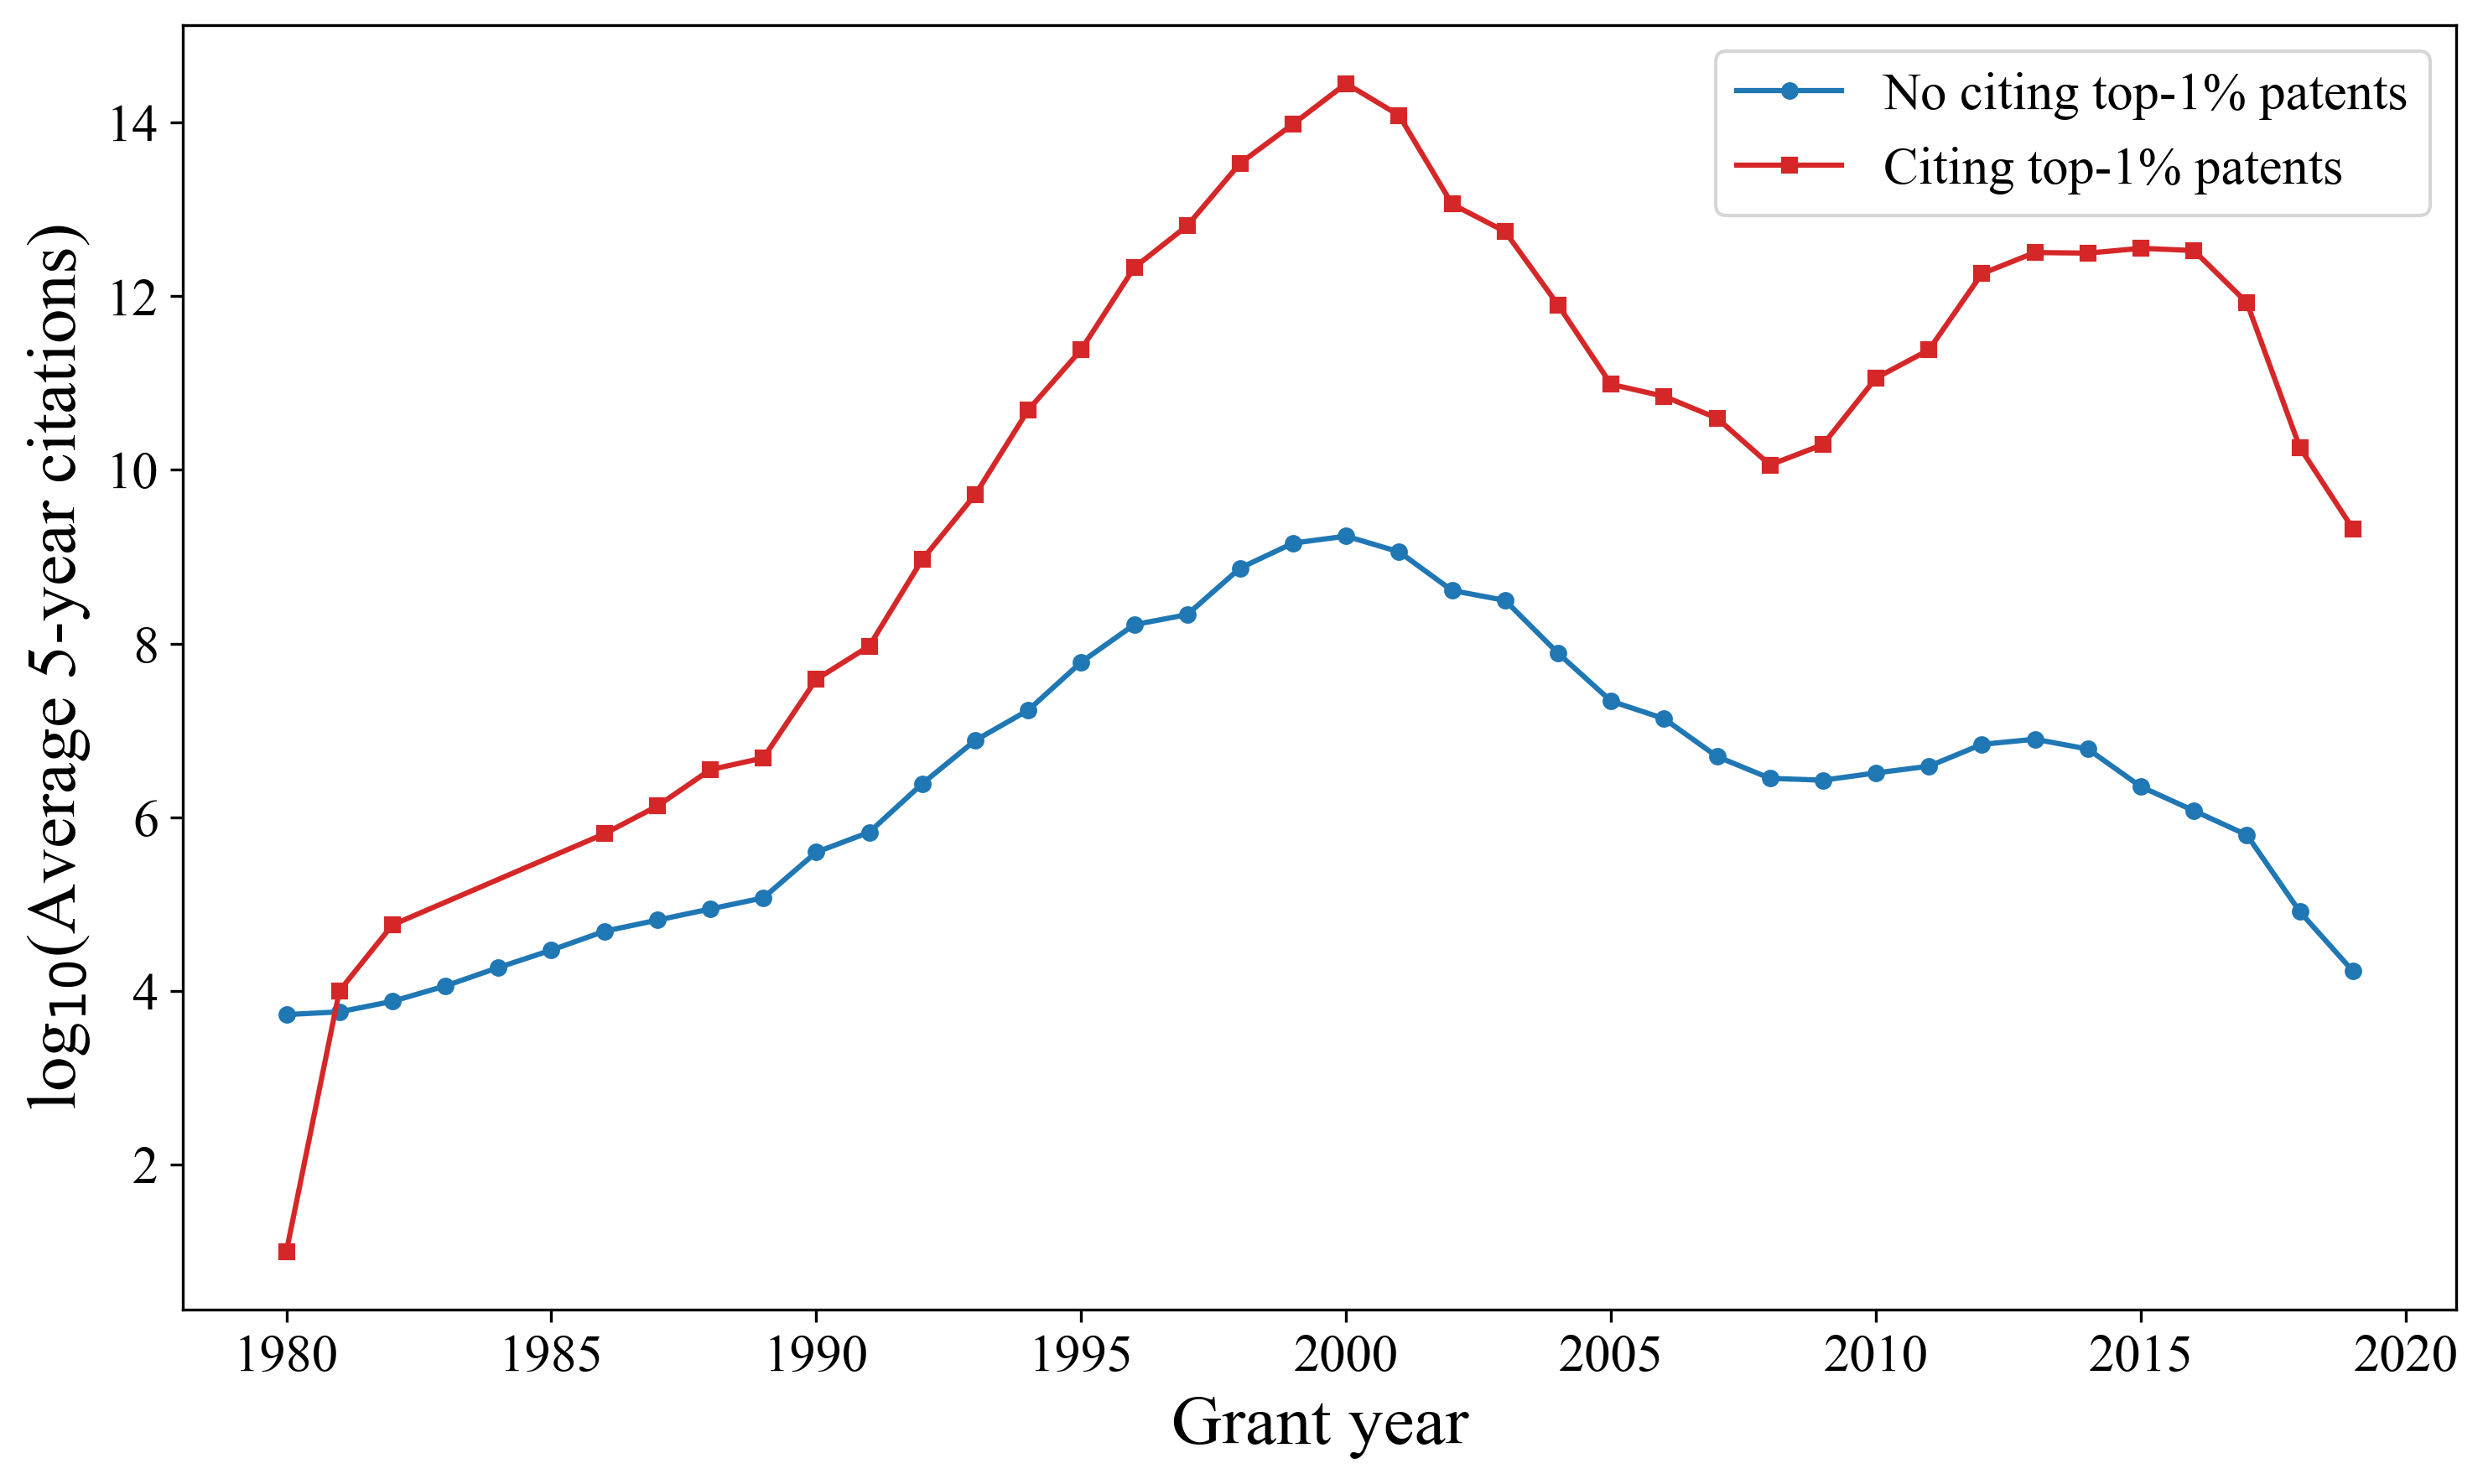

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) 未引用 top5 DI% 的专利
c1 = (
    summary
    .query("1980 <= patent_year <= 2019")
    .query("top_sum == 0")                       # 只保留 top_sum==0
    .assign(cites_5yr=lambda x: np.where(x['cites_5yr'] == 0, np.nan, x['cites_5yr']))
    .groupby('patent_year')['cites_5yr']
    .mean()
    .dropna()
    .sort_index()
)

# 2) 至少引用过 1 篇 top5 DI% 的专利
c2 = (
    summary
    .query("1980 <= patent_year <= 2019")
    .query("top_sum > 0")                        # 只保留 top_sum>0
    .assign(cites_5yr=lambda x: np.where(x['cites_5yr'] == 0, np.nan, x['cites_5yr']))
    .groupby('patent_year')['cites_5yr']
    .mean()
    .dropna()
    .sort_index()
)



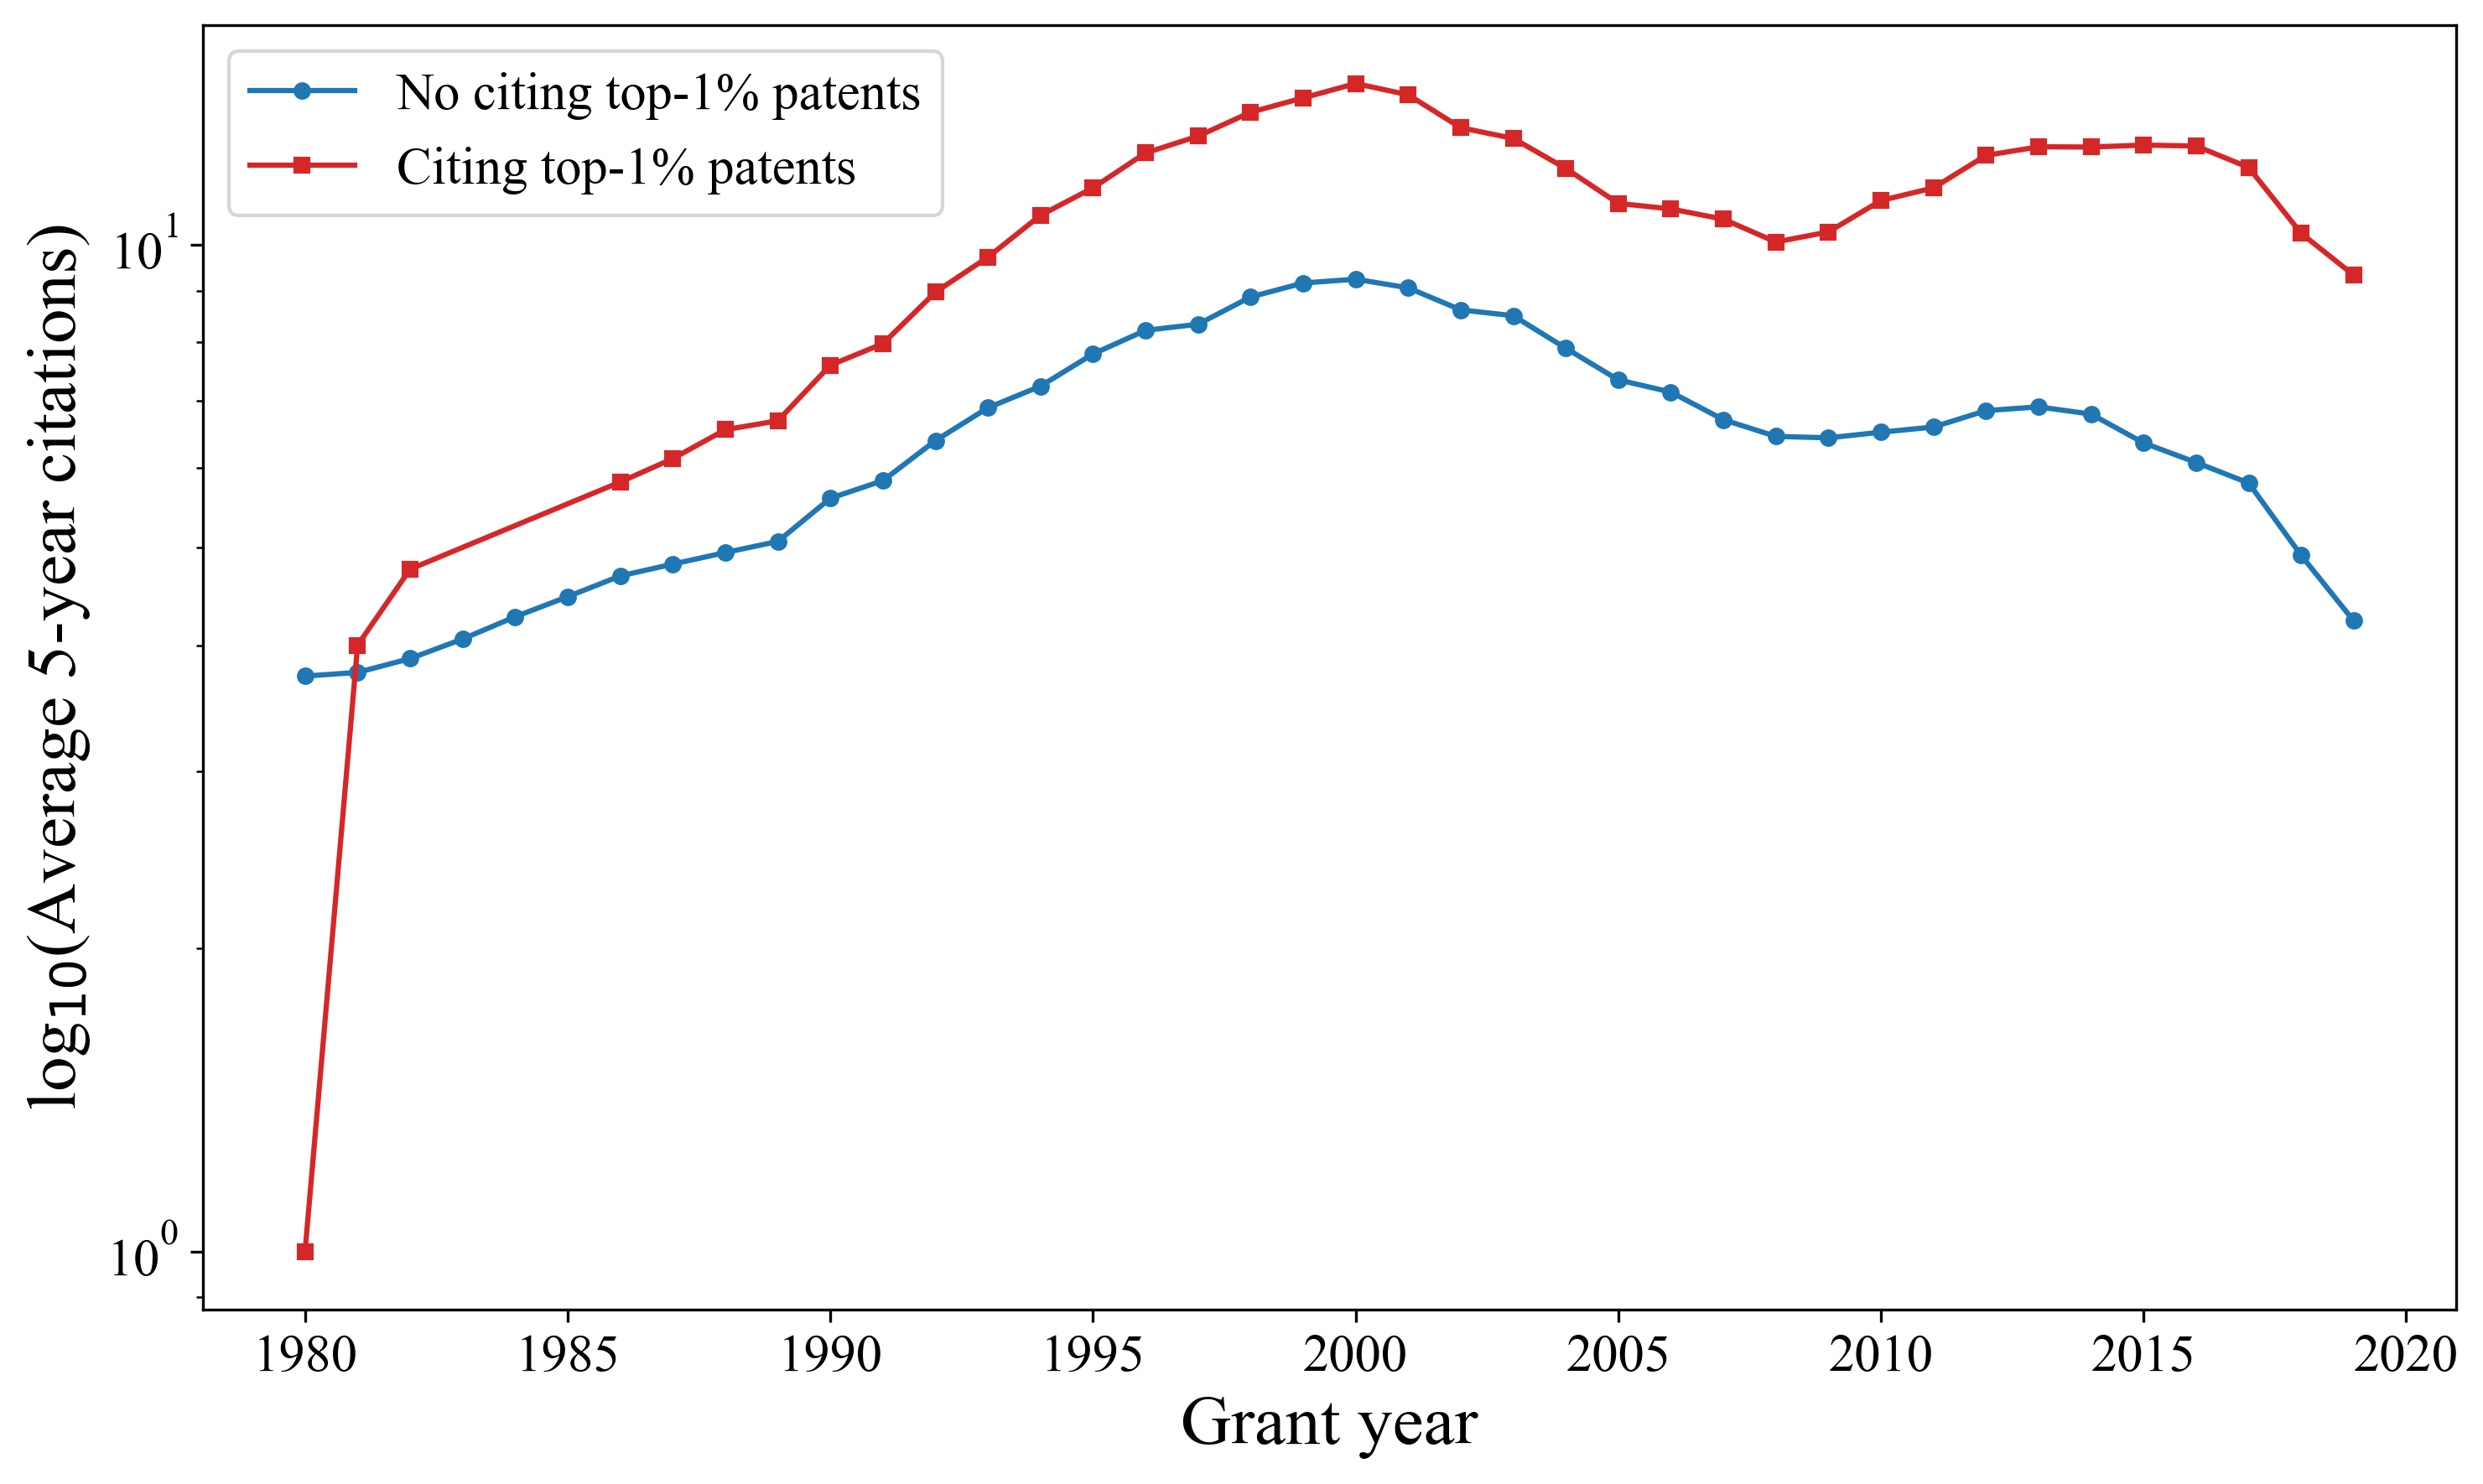

In [49]:
# --------------------------------------------------
# 3) 画两条折线（纵坐标对数）
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(c1.index, c1.values, marker='o', label='No citing top-1% patents', color='#1f77b4', lw=1.5, ms=4)
plt.plot(c2.index, c2.values, marker='s', label='Citing top-1% patents', color='#d62728', lw=1.5, ms=4)

plt.xlabel('Grant year')
plt.ylabel('log$_{10}$(Average 5-year citations)')
# plt.title('Average 5-year citations (1980–2019, log scale)')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

#### Step 6 分析引用top专利的特点

In [51]:
p2psim_di_top.head()

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,is_top,is_di_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,20.0,11.0,0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,20.0,11.0,0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,12.0,0.0,0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,12.0,0.0,0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,12.0,0.0,0,0


In [61]:
p2psim_di_top

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,is_top,is_di_top
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,20.0,11.0,0,0
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,20.0,11.0,0,0
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,12.0,0.0,0,0
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,12.0,0.0,0,0
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,12.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
111617299,4185894,RE34947,0.612,NaN,RE34947,1995.0,13.0,0.0,0,0
111617300,4368386,RE34947,0.590,NaN,RE34947,1995.0,13.0,0.0,0,0
111617301,4481531,RE34947,0.533,NaN,RE34947,1995.0,13.0,0.0,0,0
111617302,4920417,RE34947,0.822,NaN,RE34947,1995.0,13.0,0.0,0,0


In [53]:
p2psim_top_reference = p2psim_di_top[p2psim_di_top['is_di_top']>0]
p2psim_top_reference.head()

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,is_top,is_di_top
26,4194381,10000007,0.434,cited by applicant,10000007,2018.0,24.0,9.0,0,1
37,4942757,10000007,0.423,cited by applicant,10000007,2018.0,24.0,9.0,0,1
63,7250753,10000007,0.421,cited by applicant,10000007,2018.0,24.0,9.0,0,1
93,6470571,10000008,0.545,cited by applicant,10000008,2018.0,11.0,0.0,0,1
114,5288443,10000011,0.507,cited by applicant,10000011,2018.0,30.0,6.0,0,1


In [54]:
# 1) 先对 sim 做聚合
sim_stats_ = (
    p2psim_top_reference
    .groupby('citing_id')['sim']
    .agg(['max', 'min','mean', 'std'])
    .rename(columns={'max': 'sim_max',
                    'min':'sim_min',
                     'mean': 'sim_mean',
                     'std': 'sim_std',})
    .assign(sim_cv=lambda x: x['sim_std'] / x['sim_mean'])
)

In [55]:
# 如果还想把其它列也保留（例如 patent_year, num_claims 等），
# 可以先取每个 citing_id 的第一行，再合并 top_sum：
other_cols = ['patent_year', 'num_claims', 'cites_5yr']  # 按需增删
summary = (
    p2psim_top_reference.drop_duplicates(subset=['citing_id'], keep='first')
              .drop(columns=['is_top'])           # 去掉旧的 is_top
              .merge(citing_top_di, on='citing_id', how='left')
)

In [56]:
# 2) 合并到 summary
summary_top = summary.merge(sim_stats_, on='citing_id', how='left')

In [93]:
summary_top.to_csv('./citations_result/temp.csv',index=False)

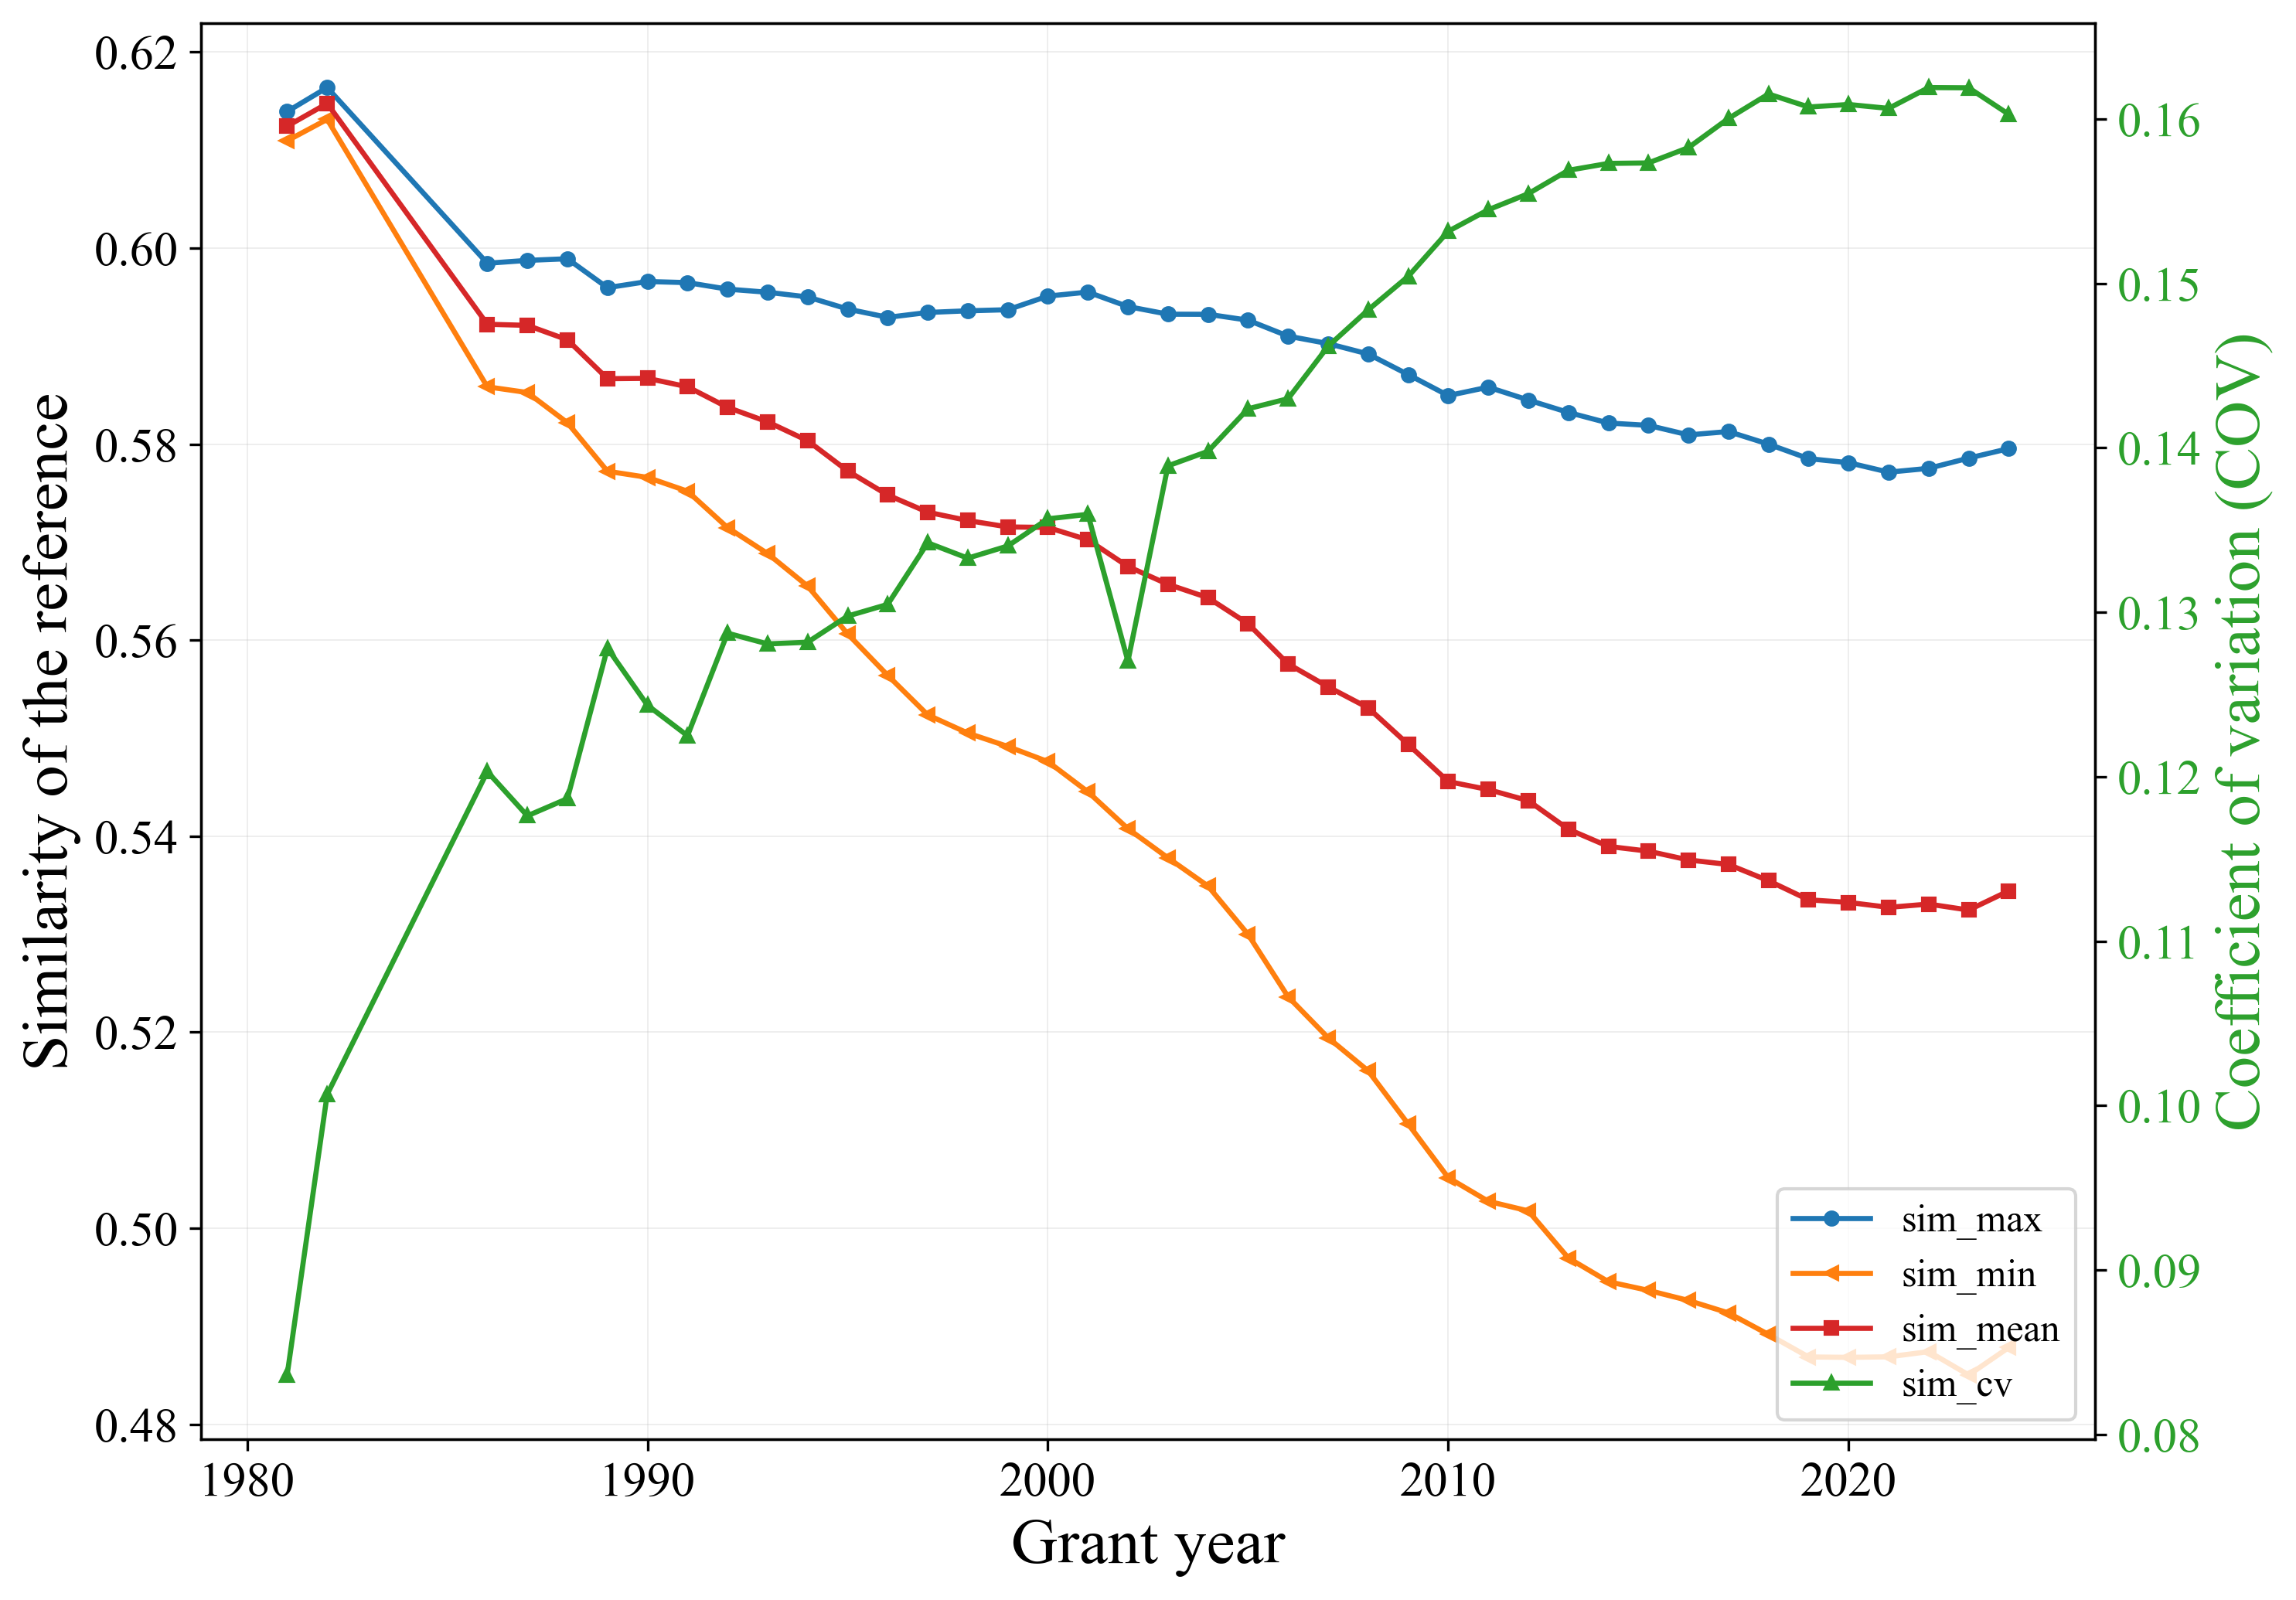

In [57]:
# 1) 数据准备（保持不变）
cols = ['sim_max', 'sim_min', 'sim_mean', 'sim_cv']
year_stats = (
    summary_top
    .query("1981 <= patent_year <= 2024")
    .groupby('patent_year')[cols]
    .mean()
    .dropna(how='all')
    .sort_index()
)

# ------------------------------------------------------------------
# 2) 柔和调色盘（主坐标轴 3 色 + 副坐标轴 1 色）
colors = {
    'sim_max':  '#1f77b4',   # 柔和蓝
    'sim_min':  '#ff7f0e',   # 柔和橙
    'sim_mean': '#d62728',   # 柔和红
    'sim_cv':   '#2ca02c'    # 柔和绿
}

# ------------------------------------------------------------------
# 3) 绘图
fig, ax1 = plt.subplots(figsize=(10, 7), dpi=300)

# 主坐标轴
for col, marker in [('sim_max', 'o'), ('sim_min', '<'), ('sim_mean', 's')]:
    ax1.plot(year_stats.index, year_stats[col],
             color=colors[col], marker=marker,
             lw=1.6, ms=4, label=col)

ax1.set_xlabel('Grant year')
ax1.set_ylabel('Similarity of the reference')
ax1.grid(alpha=0.25, lw=0.4)

# 副坐标轴
ax2 = ax1.twinx()
ax2.plot(year_stats.index, year_stats['sim_cv'],
         color=colors['sim_cv'], marker='^',
         lw=1.6, ms=4, label='sim_cv')
ax2.set_ylabel('Coefficient of variation (COV)', color=colors['sim_cv'])
ax2.tick_params(axis='y', labelcolor=colors['sim_cv'])

# 统一图例（放在图内右上角，不遮挡曲线）
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc='lower right', frameon=True, fancybox=True, shadow=False,fontsize=12)

# 细边 & 紧凑布局
ax1.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [58]:
corr = summary_top[['cites_5yr', 'sim_cv']].corr().iloc[0, 1]
print(f"Pearson r = {corr:.4f}")

Pearson r = 0.0350


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------------------------------------------------------
# 1) 取数 & 去掉 NaN
df = summary_top[['sim_mean', 'sim_cv']].dropna()

# ------------------------------------------------------------------
# 2) 计算二维核密度，用于颜色映射
xy = np.vstack([df['sim_mean'], df['sim_cv']])
kde  = gaussian_kde(xy)
z = kde(xy)

# ------------------------------------------------------------------
# 3) 绘图
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

# 散点，颜色 = 密度
sc = ax.scatter(df['sim_mean'], df['sim_cv'],
                c=z, s=15, cmap='turbo', alpha=0.9, rasterized=True)

# 可选：画 2D KDE 等高线，突出高密度区域
xi, yi = np.mgrid[df['sim_mean'].min():df['sim_mean'].max():100j,
                  df['sim_cv'].min():df['sim_cv'].max():100j]
zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
ax.contour(xi, yi, zi, levels=4, colors='k', linewidths=0.4, alpha=0.4)

# ------------------------------------------------------------------
# 4) 美化
ax.set_xlabel('Mean similarity (sim_mean)')
ax.set_ylabel('Coefficient of variation (sim_cv)')
ax.grid(alpha=0.25)

# 颜色条
cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Density')

plt.tight_layout()
plt.show()

In [59]:
summary

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,is_di_top,top_sum
0,4194381,10000007,0.434,cited by applicant,10000007,2018.0,24.0,9.0,1,3
1,6470571,10000008,0.545,cited by applicant,10000008,2018.0,11.0,0.0,1,1
2,5288443,10000011,0.507,cited by applicant,10000011,2018.0,30.0,6.0,1,1
3,9680187,10000018,0.722,cited by applicant,10000018,2018.0,13.0,1.0,1,1
4,7125512,10000021,0.559,cited by examiner,10000021,2018.0,4.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...
2529433,6202798,9975736,0.586,cited by examiner,9975736,2018.0,8.0,0.0,1,3
2529434,4493463,9975745,0.606,cited by applicant,9975745,2018.0,8.0,1.0,1,4
2529435,4605203,9975747,0.691,cited by examiner,9975747,2018.0,20.0,1.0,1,1
2529436,4245666,9975751,0.688,cited by applicant,9975751,2018.0,10.0,0.0,1,1


####  Step 6 分析颠覆性和相似度的关系

In [65]:
p2psim_top_reference

,cited_id,citing_id,sim,cited_by,patent_id,patent_year,num_claims,cites_5yr,is_top,is_di_top
26,4194381,10000007,0.434,cited by applicant,10000007,2018.0,24.0,9.0,0,1
37,4942757,10000007,0.423,cited by applicant,10000007,2018.0,24.0,9.0,0,1
63,7250753,10000007,0.421,cited by applicant,10000007,2018.0,24.0,9.0,0,1
93,6470571,10000008,0.545,cited by applicant,10000008,2018.0,11.0,0.0,0,1
114,5288443,10000011,0.507,cited by applicant,10000011,2018.0,30.0,6.0,0,1
...,...,...,...,...,...,...,...,...,...,...
111617186,7934674,9975745,0.422,cited by applicant,9975745,2018.0,8.0,1.0,0,1
111617188,8151661,9975745,0.542,cited by applicant,9975745,2018.0,8.0,1.0,0,1
111617195,4605203,9975747,0.691,cited by examiner,9975747,2018.0,20.0,1.0,0,1
111617246,4245666,9975751,0.688,cited by applicant,9975751,2018.0,10.0,0.0,0,1


In [76]:
p2psim_top_reference['citing_id'] = p2psim_top_reference['citing_id'].astype('str')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15220\2029464824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p2psim_top_reference['citing_id'] = p2psim_top_reference['citing_id'].astype('str')


In [67]:
d_index_df

,patent_id,d_index
0,D580322,-0.369369
1,D620599,-0.107843
2,D633181,0.038710
3,D792235,-0.086667
4,D337815,-0.010638
...,...,...
6313901,D584754,0.010490
6313902,D251839,0.070175
6313903,D360478,0.089286
6313904,D819242,0.015317


In [77]:
# 三次 merge
result = p2psim_top_reference \
    .merge(d_index_df.rename(columns={'d_index': 'cited_d_index'}), left_on='cited_id', right_on='patent_id', how='left') \
    .merge(d_index_df.rename(columns={'d_index': 'citing_d_index'}), left_on='citing_id', right_on='patent_id', how='left') 

In [78]:
result

,cited_id,citing_id,sim,cited_by,patent_id_x,patent_year,num_claims,cites_5yr,is_top,is_di_top,patent_id_y,cited_d_index,patent_id,citing_d_index
0,4194381,10000007,0.434,cited by applicant,10000007,2018.0,24.0,9.0,0,1,4194381,0.611111,10000007,-0.012500
1,4942757,10000007,0.423,cited by applicant,10000007,2018.0,24.0,9.0,0,1,4942757,0.402778,10000007,-0.012500
2,7250753,10000007,0.421,cited by applicant,10000007,2018.0,24.0,9.0,0,1,7250753,0.414634,10000007,-0.012500
3,6470571,10000008,0.545,cited by applicant,10000008,2018.0,11.0,0.0,0,1,6470571,0.333333,NaN,NaN
4,5288443,10000011,0.507,cited by applicant,10000011,2018.0,30.0,6.0,0,1,5288443,0.382979,10000011,-0.000638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10968017,7934674,9975745,0.422,cited by applicant,9975745,2018.0,8.0,1.0,0,1,7934674,0.303030,9975745,0.005362
10968018,8151661,9975745,0.542,cited by applicant,9975745,2018.0,8.0,1.0,0,1,8151661,0.321799,9975745,0.005362
10968019,4605203,9975747,0.691,cited by examiner,9975747,2018.0,20.0,1.0,0,1,4605203,0.470588,9975747,0.000000
10968020,4245666,9975751,0.688,cited by applicant,9975751,2018.0,10.0,0.0,0,1,4245666,0.525000,9975751,-0.001449


In [79]:
result['delta_d'] = result['citing_d_index'] - result['cited_d_index']

In [80]:
result

,cited_id,citing_id,sim,cited_by,patent_id_x,patent_year,num_claims,cites_5yr,is_top,is_di_top,patent_id_y,cited_d_index,patent_id,citing_d_index,delta_d
0,4194381,10000007,0.434,cited by applicant,10000007,2018.0,24.0,9.0,0,1,4194381,0.611111,10000007,-0.012500,-0.623611
1,4942757,10000007,0.423,cited by applicant,10000007,2018.0,24.0,9.0,0,1,4942757,0.402778,10000007,-0.012500,-0.415278
2,7250753,10000007,0.421,cited by applicant,10000007,2018.0,24.0,9.0,0,1,7250753,0.414634,10000007,-0.012500,-0.427134
3,6470571,10000008,0.545,cited by applicant,10000008,2018.0,11.0,0.0,0,1,6470571,0.333333,NaN,NaN,NaN
4,5288443,10000011,0.507,cited by applicant,10000011,2018.0,30.0,6.0,0,1,5288443,0.382979,10000011,-0.000638,-0.383617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10968017,7934674,9975745,0.422,cited by applicant,9975745,2018.0,8.0,1.0,0,1,7934674,0.303030,9975745,0.005362,-0.297668
10968018,8151661,9975745,0.542,cited by applicant,9975745,2018.0,8.0,1.0,0,1,8151661,0.321799,9975745,0.005362,-0.316437
10968019,4605203,9975747,0.691,cited by examiner,9975747,2018.0,20.0,1.0,0,1,4605203,0.470588,9975747,0.000000,-0.470588
10968020,4245666,9975751,0.688,cited by applicant,9975751,2018.0,10.0,0.0,0,1,4245666,0.525000,9975751,-0.001449,-0.526449


In [81]:
corr = result[['sim', 'delta_d']].corr(method='pearson')  # 也可换 spearman
print(corr)

              sim   delta_d
sim      1.000000  0.103407
delta_d  0.103407  1.000000


In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1) 分箱（保留小数点后两位，标签更简洁）
result['sim_bin'] = pd.qcut(result['sim'], q=5, precision=2)

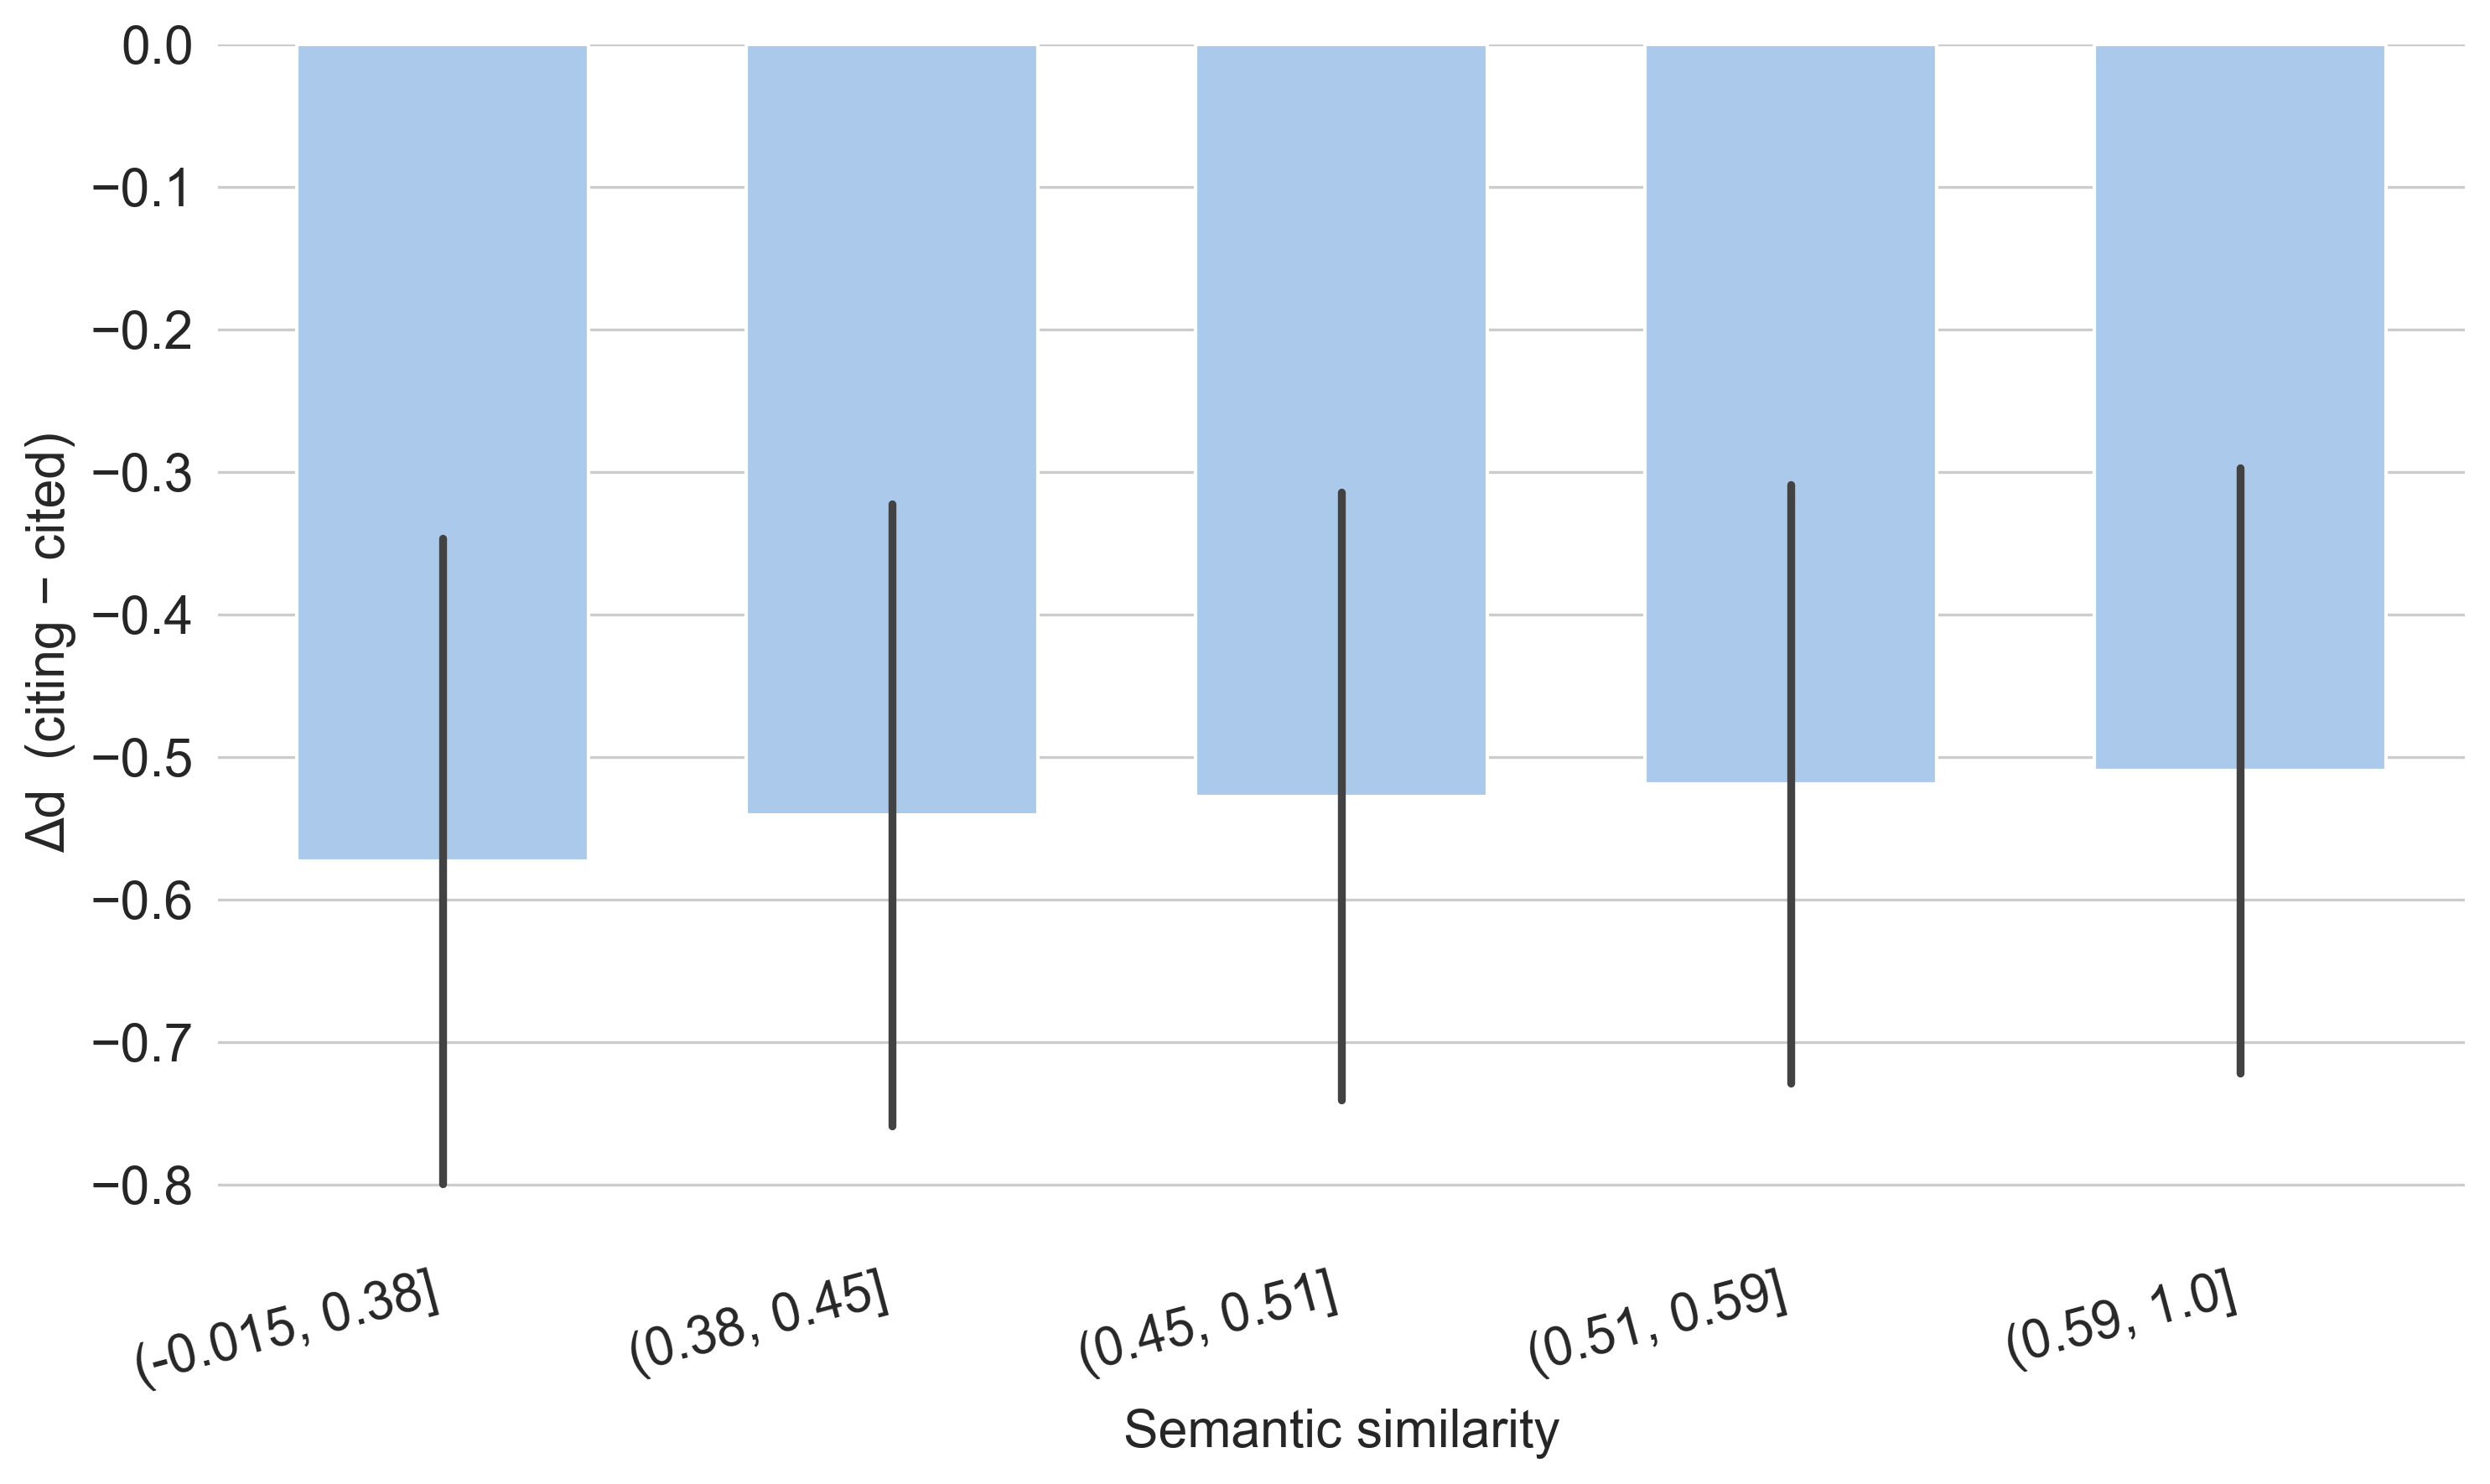

In [89]:
# 2) 绘图
plt.figure(figsize=(10, 6),dpi=300)
sns.set_style('whitegrid')               # 清爽网格
sns.set_palette('pastel')                # 柔和配色

ax = sns.barplot(
    data=result,
    x='sim_bin',
    y='delta_d',
    errorbar='sd',                             # 显示 ±1 SD 误差棒
    width=0.65
)

# 3) 美化细节
ax.set_xlabel('Semantic similarity', fontsize=15)
ax.set_ylabel('Δd  (citing − cited)', fontsize=15)
plt.xticks(rotation=15, ha='right')
sns.despine(left=True, bottom=True)      # 去掉多余边框
plt.tight_layout()
plt.show()

In [90]:
top_per_citing = (
    result
    .sort_values('cited_d_index', ascending=False)  # 先按 cited_d_index 降序
    .drop_duplicates(subset=['citing_id'], keep='first')  # 每组仅保留最大
    .reset_index(drop=True)
)

In [91]:
top_per_citing

,cited_id,citing_id,sim,cited_by,patent_id_x,patent_year,num_claims,cites_5yr,is_top,is_di_top,patent_id_y,cited_d_index,patent_id,citing_d_index,delta_d,sim_bin
0,4213562,9750499,0.423,cited by applicant,9750499,2017.0,10.0,1074.0,0,1,4213562,0.999305,9750499,-0.021578,-1.020882,"(0.38, 0.45]"
1,4213562,9351727,0.477,cited by applicant,9351727,2016.0,20.0,1323.0,0,1,4213562,0.999305,9351727,-0.029232,-1.028537,"(0.45, 0.51]"
2,4213562,10588625,0.318,cited by applicant,10588625,2020.0,20.0,439.0,0,1,4213562,0.999305,10588625,-0.009398,-1.008703,"(-0.015, 0.38]"
3,4213562,11478242,0.317,cited by applicant,11478242,2022.0,24.0,38.0,0,1,4213562,0.999305,11478242,-0.000915,-1.000219,"(-0.015, 0.38]"
4,4213562,10517596,0.310,cited by applicant,10517596,2019.0,20.0,622.0,0,1,4213562,0.999305,10517596,-0.010289,-1.009594,"(-0.015, 0.38]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2529432,7117096,8435517,0.501,cited by applicant,8435517,2013.0,8.0,8.0,0,1,7117096,0.158416,8435517,-0.003442,-0.161858,"(0.45, 0.51]"
2529433,7117096,8412461,0.618,cited by applicant,8412461,2013.0,75.0,1.0,0,1,7117096,0.158416,8412461,0.046053,-0.112363,"(0.59, 1.0]"
2529434,7117096,9102711,0.471,cited by applicant,9102711,2015.0,8.0,1.0,0,1,7117096,0.158416,9102711,-0.000566,-0.158981,"(0.45, 0.51]"
2529435,7117096,8005620,0.487,cited by other,8005620,2011.0,44.0,4.0,0,1,7117096,0.158416,8005620,0.121212,-0.037204,"(0.45, 0.51]"


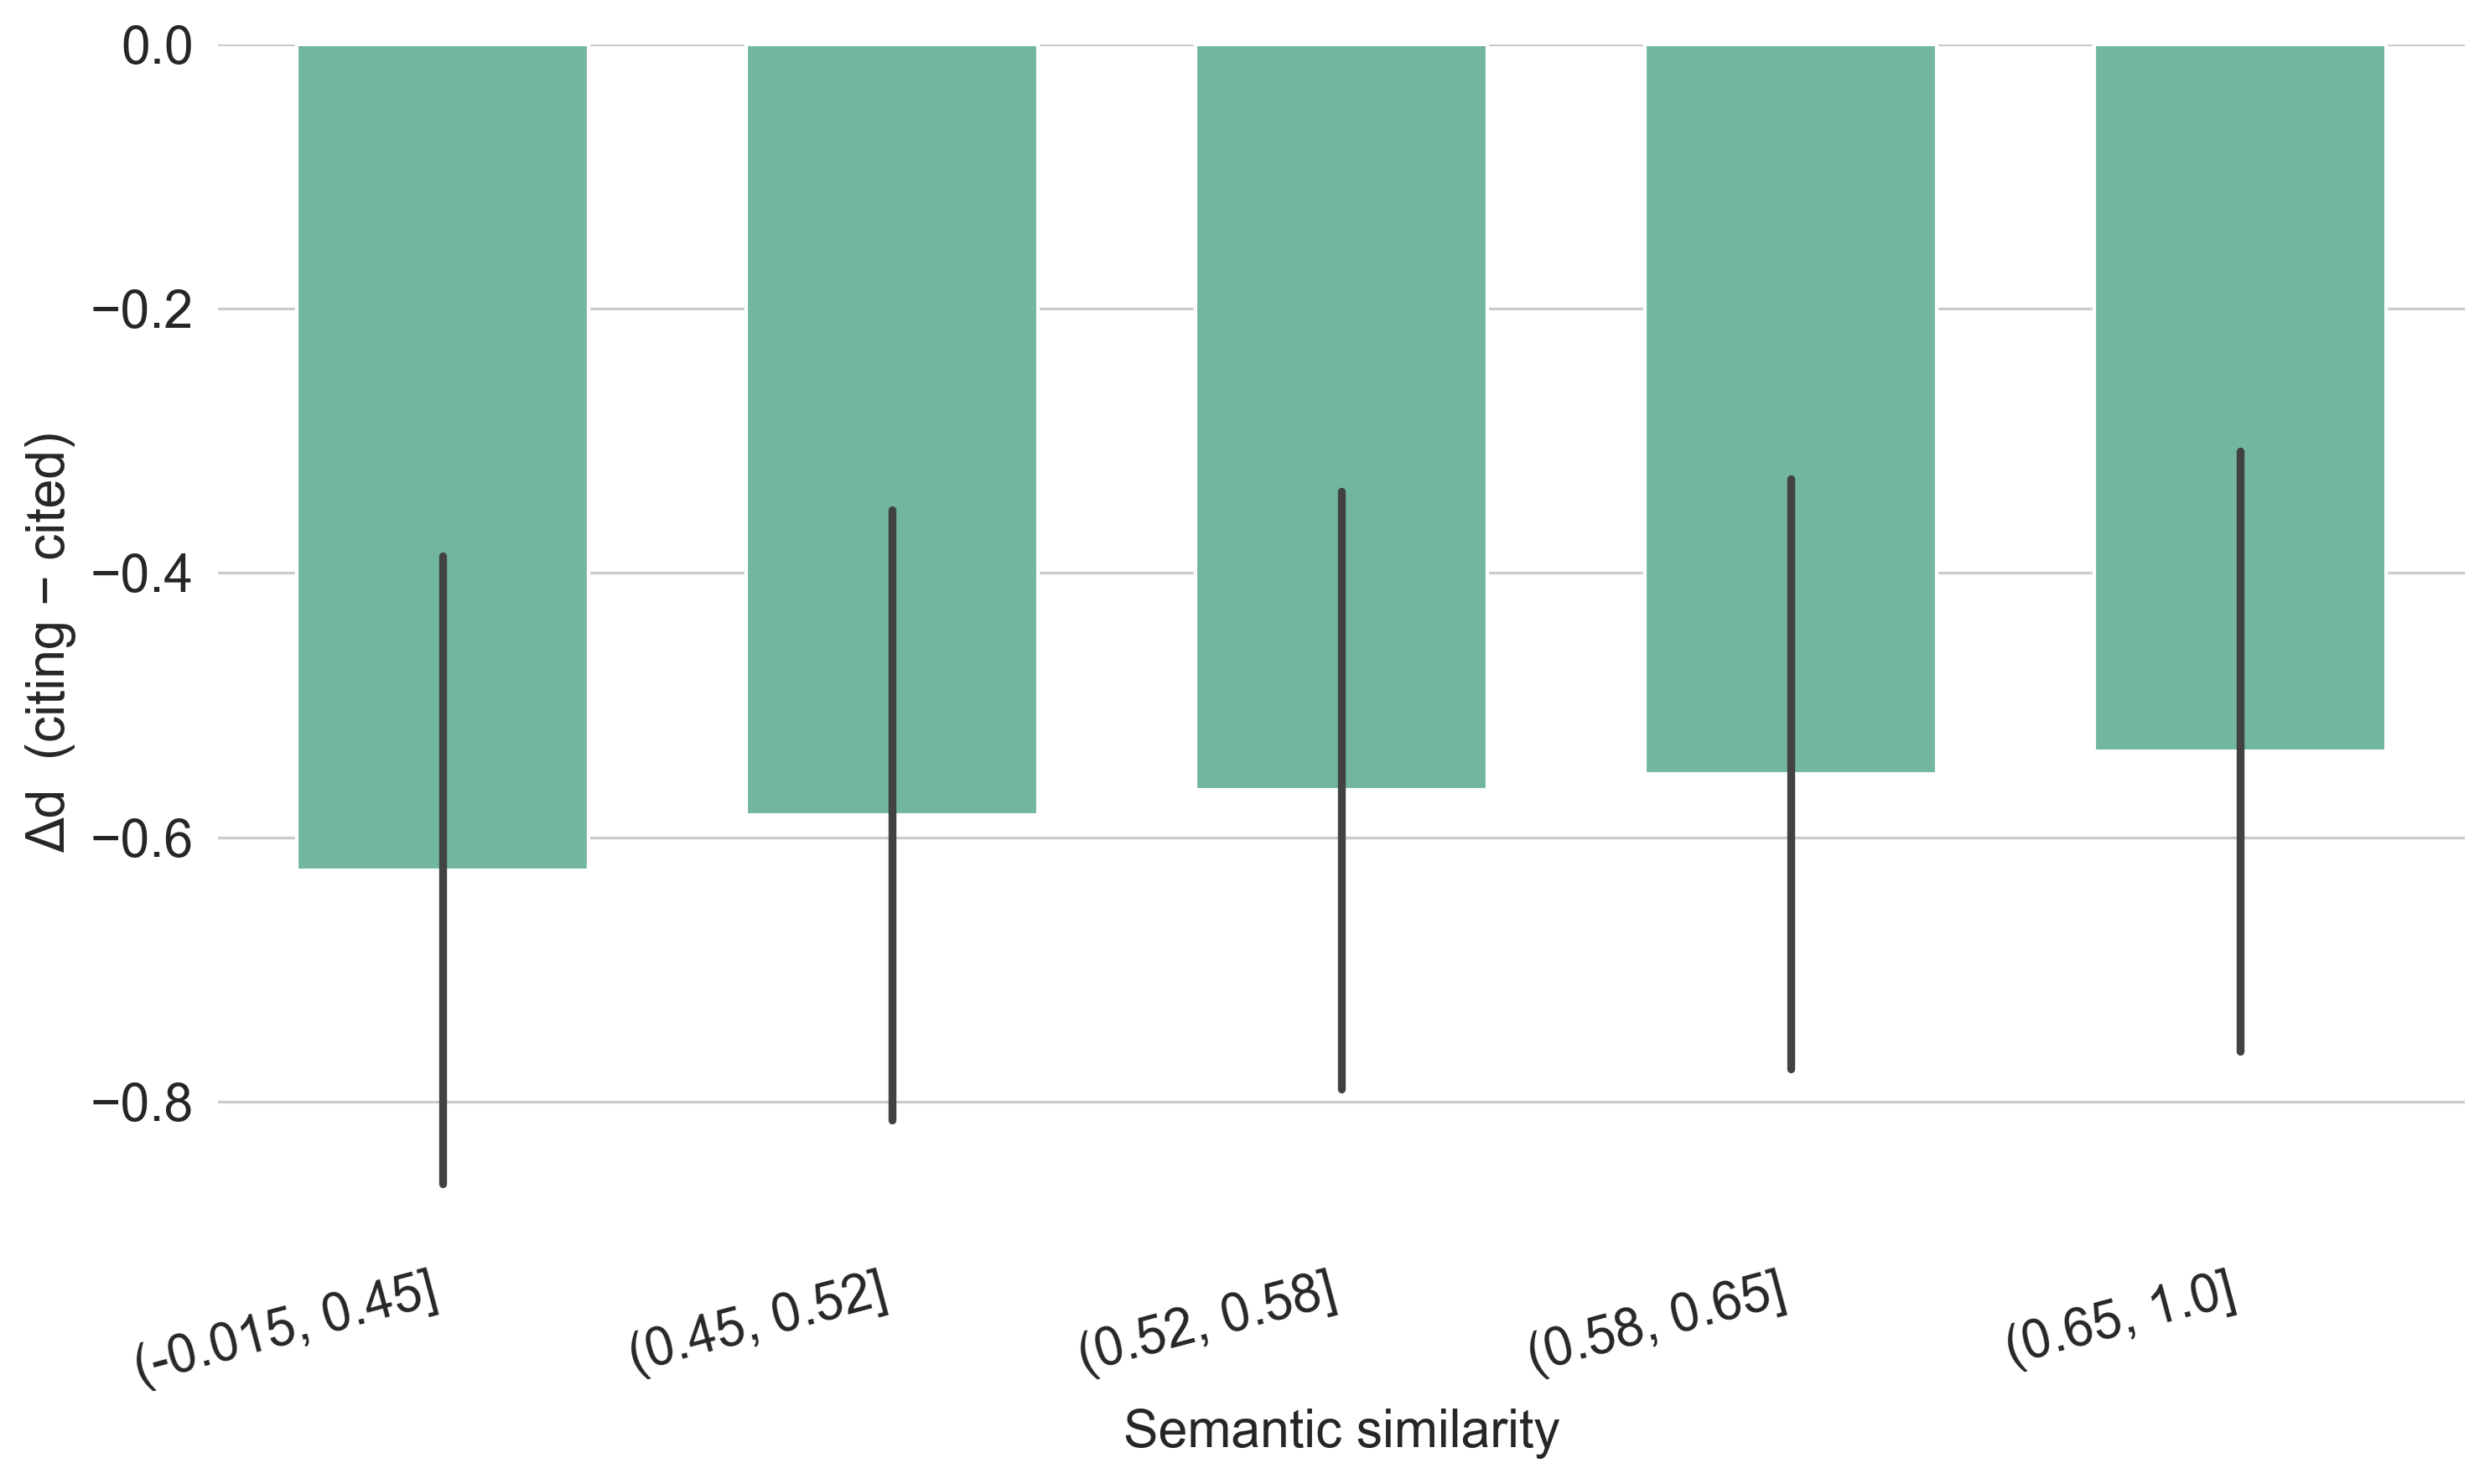

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2) 分箱
top_per_citing['sim_bin'] = pd.qcut(top_per_citing['sim'], q=5, precision=2)

# 3) 画图
plt.figure(figsize=(10, 6), dpi=300)
sns.set_style('whitegrid')
sns.set_palette('Set2')                  # ← 换成更鲜明的颜色

ax = sns.barplot(
    data=top_per_citing,
    x='sim_bin',
    y='delta_d',
    errorbar='sd',                       # 误差棒：±1 SD
    width=0.65
)

# 4) 美化
ax.set_xlabel('Semantic similarity', fontsize=15)
ax.set_ylabel('Δd  (citing − cited)', fontsize=15)
plt.xticks(rotation=15, ha='right')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

##### 分析全部的

In [104]:
p2psim_di_top['citing_id'] =  p2psim_di_top['citing_id'].astype('str')

In [105]:
# 三次 merge
result_total = p2psim_di_top \
    .merge(d_index_df.rename(columns={'d_index': 'cited_d_index'}), left_on='cited_id', right_on='patent_id', how='left') \
    .merge(d_index_df.rename(columns={'d_index': 'citing_d_index'}), left_on='citing_id', right_on='patent_id', how='left') 

In [106]:
result_total['delta_d'] = result_total['citing_d_index'] - result_total['cited_d_index']

In [107]:
result_total

,cited_id,citing_id,sim,cited_by,patent_id_x,patent_year,num_claims,cites_5yr,is_top,is_di_top,patent_id_y,cited_d_index,patent_id,citing_d_index,delta_d
0,5093563,10000000,0.619,cited by examiner,10000000,2018.0,20.0,11.0,0,0,5093563,0.246073,10000000,0.041667,-0.204407
1,5751830,10000000,0.675,cited by applicant,10000000,2018.0,20.0,11.0,0,0,5751830,0.043275,10000000,0.041667,-0.001608
2,7804268,10000001,0.695,cited by examiner,10000001,2018.0,12.0,0.0,0,0,7804268,0.029412,NaN,NaN,NaN
3,9022767,10000001,0.788,cited by examiner,10000001,2018.0,12.0,0.0,0,0,9022767,0.034483,NaN,NaN,NaN
4,9090016,10000001,0.673,cited by examiner,10000001,2018.0,12.0,0.0,0,0,9090016,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111617299,4185894,RE34947,0.612,NaN,RE34947,1995.0,13.0,0.0,0,0,4185894,0.176471,RE34947,0.050725,-0.125746
111617300,4368386,RE34947,0.590,NaN,RE34947,1995.0,13.0,0.0,0,0,4368386,0.131313,RE34947,0.050725,-0.080588
111617301,4481531,RE34947,0.533,NaN,RE34947,1995.0,13.0,0.0,0,0,4481531,0.084615,RE34947,0.050725,-0.033891
111617302,4920417,RE34947,0.822,NaN,RE34947,1995.0,13.0,0.0,0,0,4920417,0.005464,RE34947,0.050725,0.045260


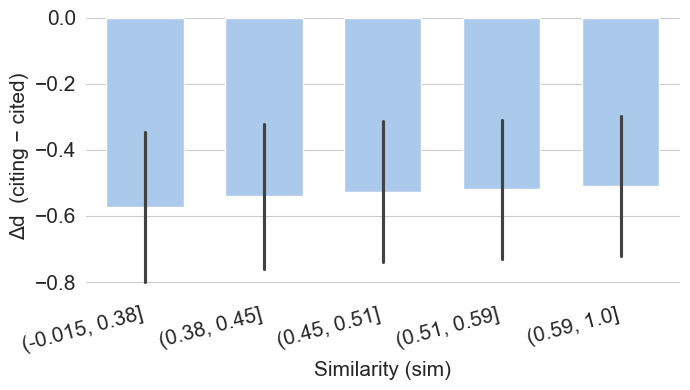

In [109]:
# 1) 分箱（保留小数点后两位，标签更简洁）
result['sim_bin'] = pd.qcut(result['sim'], q=5, precision=2)

# 2) 绘图
plt.figure(figsize=(7, 4))
sns.set_style('whitegrid')               # 清爽网格
sns.set_palette('pastel')                # 柔和配色

ax = sns.barplot(
    data=result,
    x='sim_bin',
    y='delta_d',
    errorbar='sd',                             # 显示 ±1 SD 误差棒
    width=0.65
)

# 3) 美化细节
ax.set_xlabel('Similarity (sim)', fontsize=15)
ax.set_ylabel('Δd  (citing − cited)', fontsize=15)
plt.xticks(rotation=15, ha='right')
sns.despine(left=True, bottom=True)      # 去掉多余边框
plt.tight_layout()
plt.show()

In [110]:
from scipy.stats import ttest_ind

# 1) 计算每个 cited_id 的 max(sim) 与 max(citing_d_index)
agg = result.groupby('cited_id').agg(
    max_sim=('sim', 'max'),
    max_ci=('citing_d_index', 'max')
).reset_index()

# 2) 把这两个最大值 merge 回原表，再筛选“双高”记录
tmp = result.merge(agg, on='cited_id', how='left')
dual_high = tmp[
    (tmp['sim'] == tmp['max_sim']) &
    (tmp['citing_d_index'] == tmp['max_ci'])
].copy()

# 3) 把原表拆成两类：双高 vs 非双高
result['is_dual_high'] = result.index.isin(dual_high.index)

双高论文数量: 46253
其余论文数量: 10921769

五年被引均值  —  双高: 5.39
五年被引均值  —  其余: 36.57
Welch t-test p-value: 0.0000


In [113]:
# 2. 按 citing_id 聚合：只要有一个 True → True
citing_flag = (
    result.groupby('citing_id')['is_dual_high']
          .any()               # 只要组里出现 True，就是 True
          .astype(bool)
)

# 3. 把结果映射回整张表
result['is_dual_high_any'] = result['citing_id'].map(citing_flag)

In [115]:
# 按 citing_id 分组，对每组保留 cited_d_index 最大的一行
dedup = (result
         .sort_values('cited_d_index', ascending=False)
         .drop_duplicates(subset=['citing_id'], keep='first')
         .reset_index(drop=True))

In [119]:
dual = dedup[dedup['is_dual_high']]
other = dedup[~dedup['is_dual_high']]

# 4) 统计描述
print('双高论文数量:', len(dual))
print('其余论文数量:', len(other))
print()
print('五年被引均值  —  双高: {:.2f}'.format(dual['cites_5yr'].mean()))
print('五年被引均值  —  其余: {:.2f}'.format(other['cites_5yr'].mean()))

# 5) 简单 t 检验
t, p = ttest_ind(dual['cites_5yr'].dropna(),
                 other['cites_5yr'].dropna(),
                 equal_var=False)
print('Welch t-test p-value: {:.4f}'.format(p))

双高论文数量: 32043
其余论文数量: 2497394

五年被引均值  —  双高: 5.21
五年被引均值  —  其余: 7.45
Welch t-test p-value: 0.0000


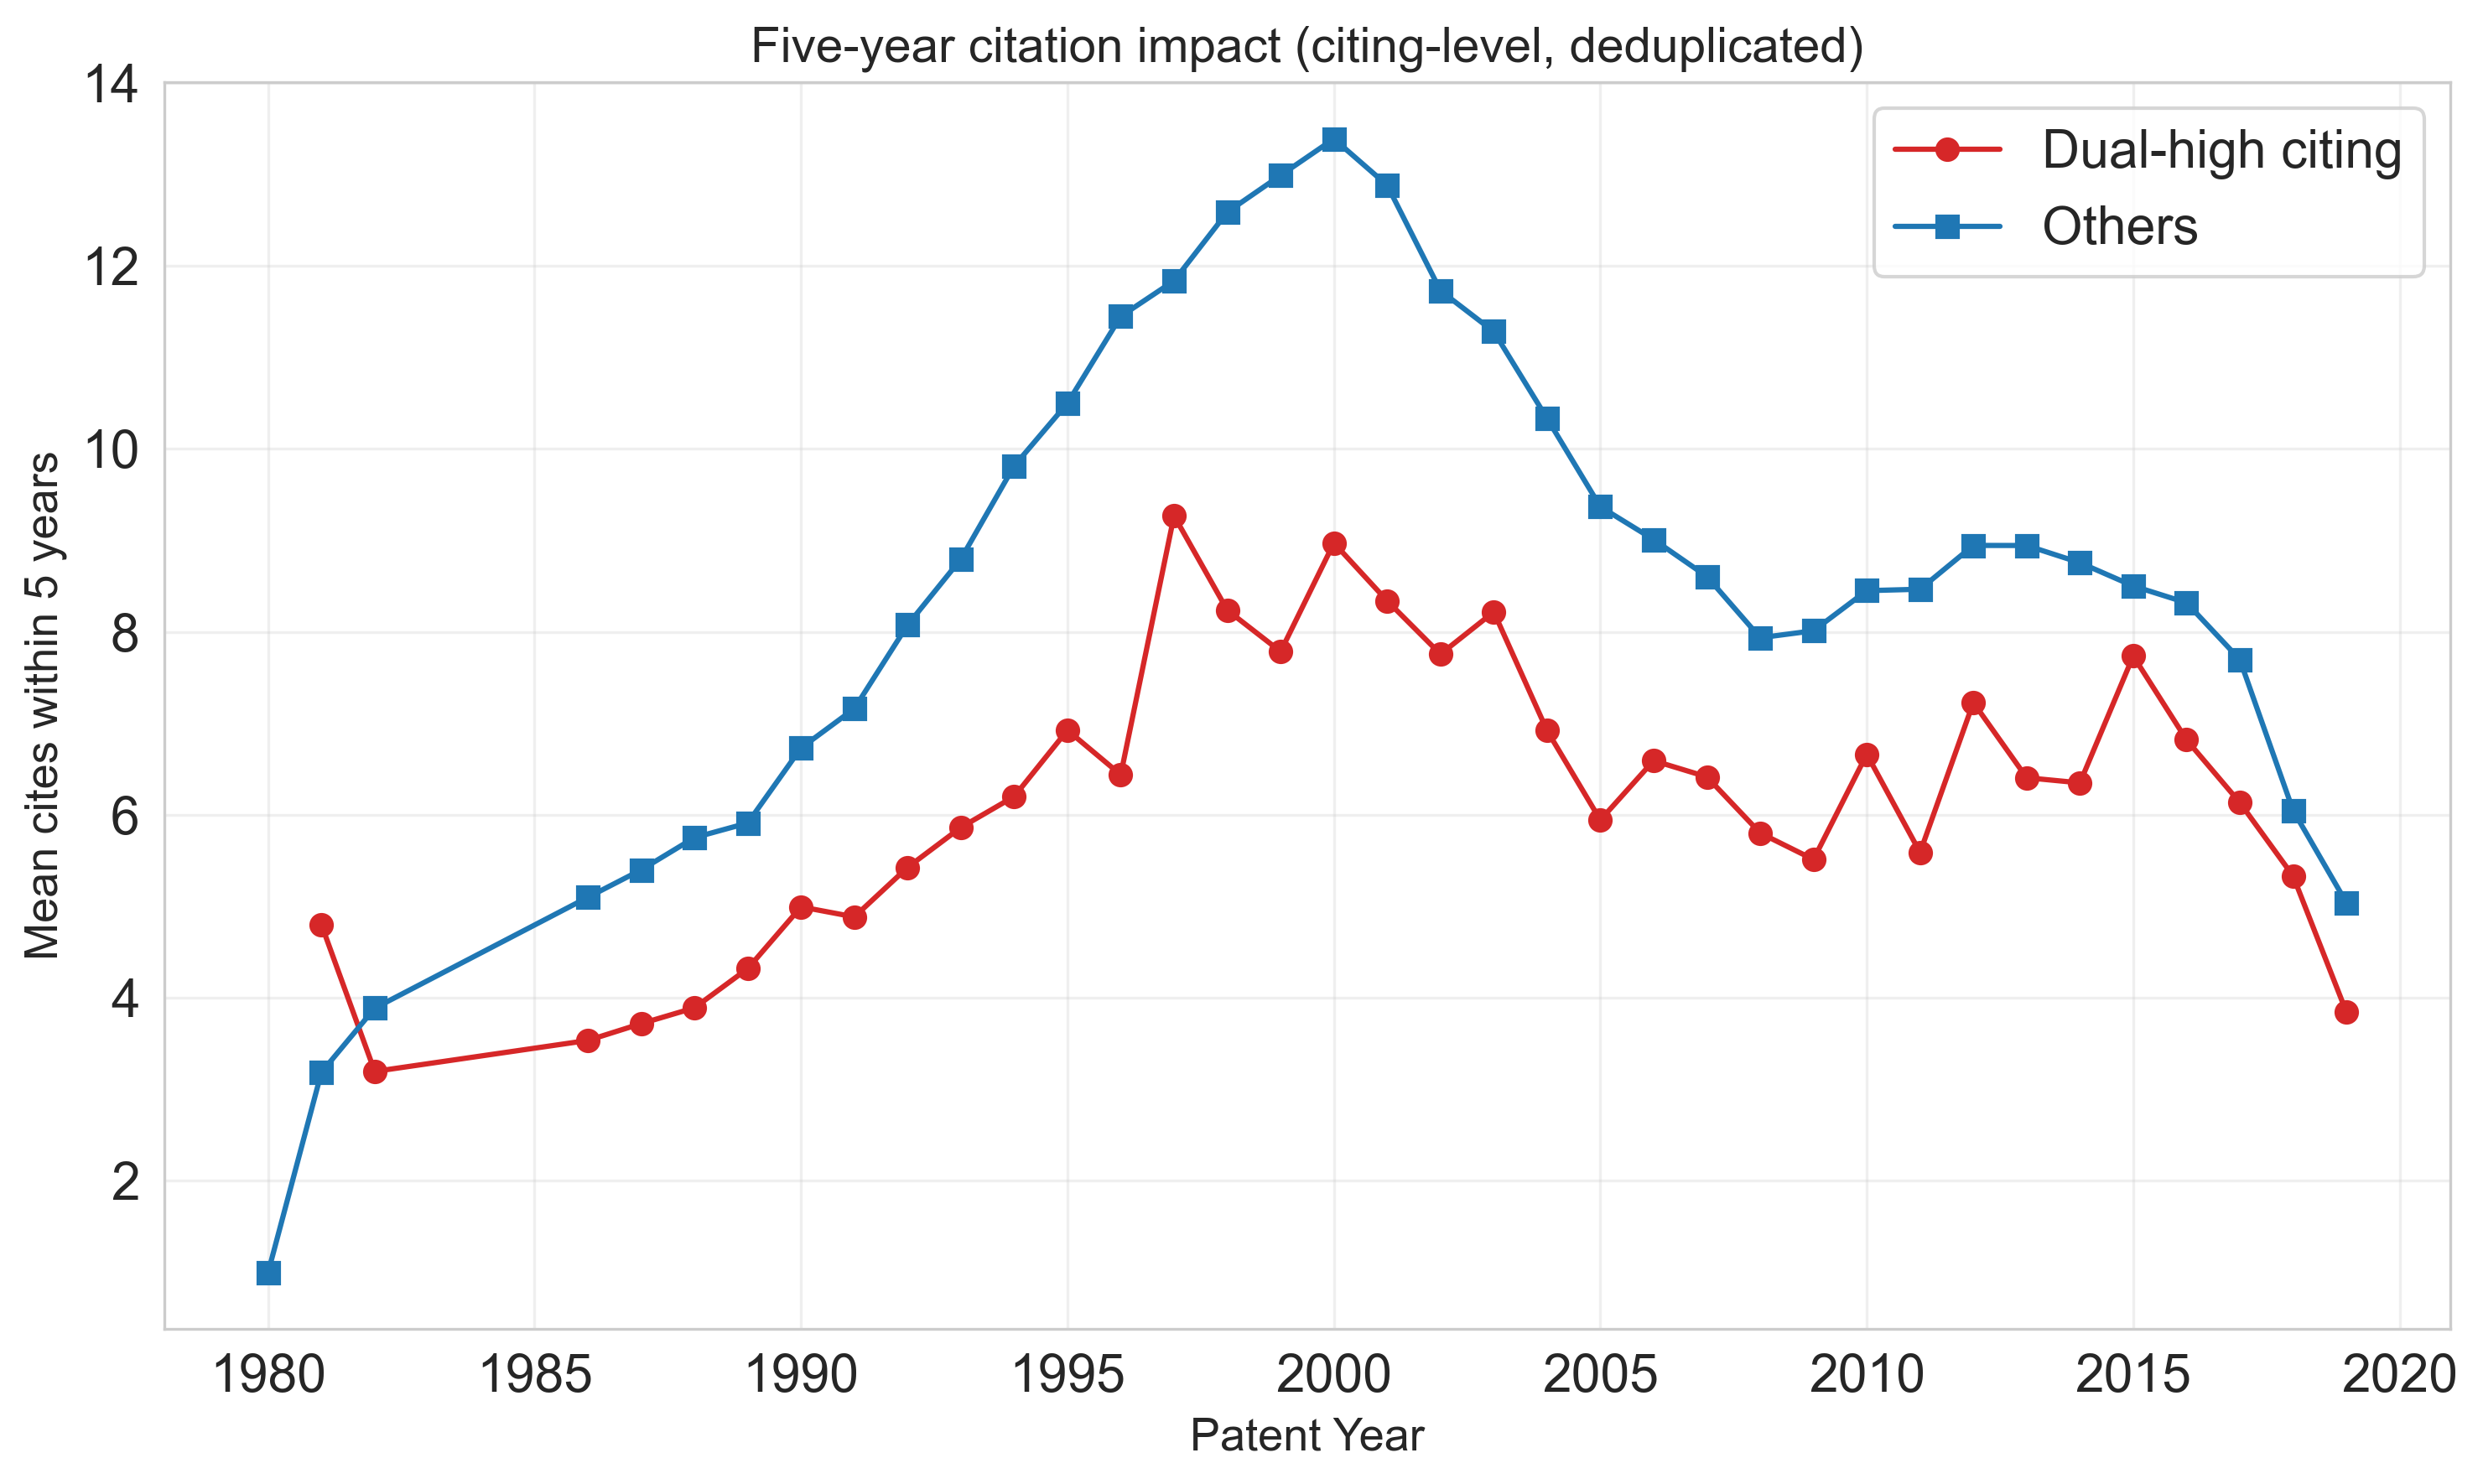

In [120]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. 生成绘图数据（已按 citing_id 去重） ---
year_stats = (
    dedup
    .groupby(['patent_year', 'is_dual_high_any'])['cites_5yr']
    .mean()
    .reset_index(name='mean_cites_5yr')
    .query("1980 <= patent_year <= 2019")      # 仅保留 1980-2019
    .sort_values('patent_year')
)

# --- 2. 拆成两条线 ---
df_true  = year_stats[year_stats['is_dual_high_any']]
df_false = year_stats[~year_stats['is_dual_high_any']]

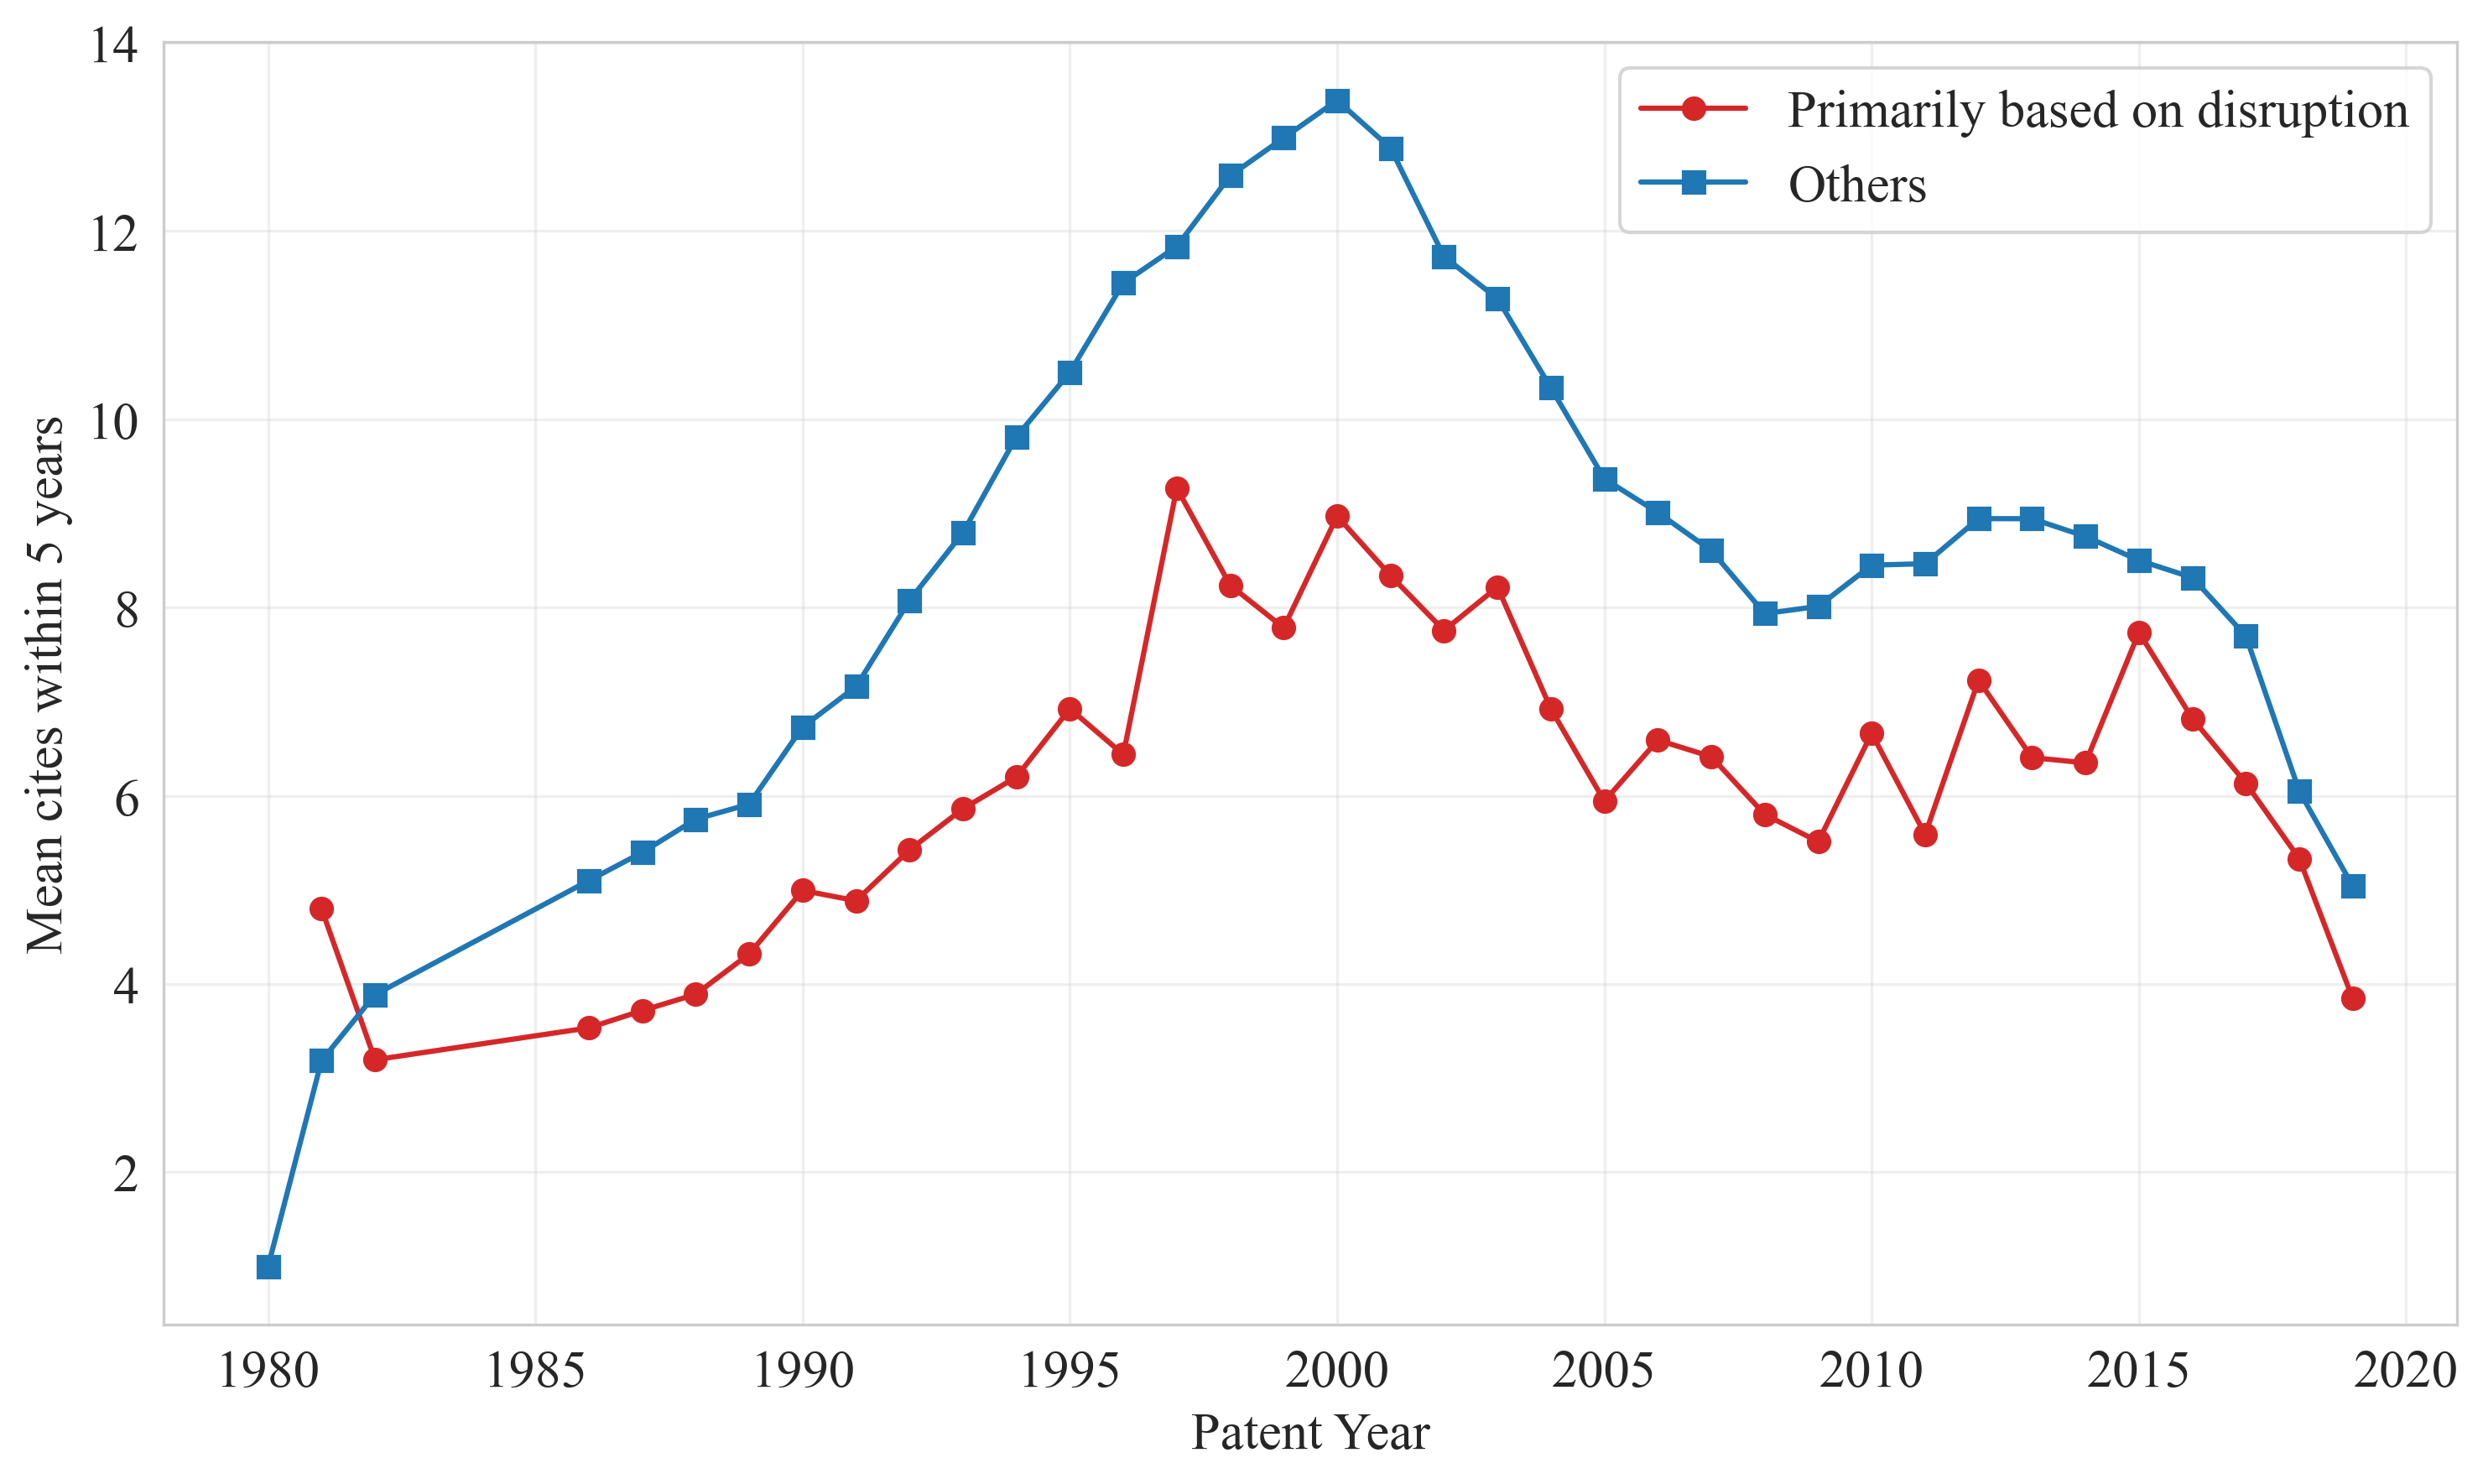

In [125]:
# --- 3. 画图 ---
plt.figure(figsize=(10, 6), dpi=300)

plt.plot(
    df_true['patent_year'],  df_true['mean_cites_5yr'],
    marker='o', linestyle='-', color='#d62728', label='Primarily based on disruption'
)
plt.plot(
    df_false['patent_year'], df_false['mean_cites_5yr'],
    marker='s', linestyle='-', color='#1f77b4', label='Others'
)

plt.xlabel('Patent Year', fontsize=15)
plt.ylabel('Mean cites within 5 years', fontsize=15)
# plt.title('Five-year citation impact (citing-level, deduplicated)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()